# Tennessee Eastman Process (TEP): Synthetic data generation and domain bridging
Building directly upon the empirical domain-shift characterization from **Stage 2**, 
we deploy **Conditional Variational Autoencoders (CVAE)** and **Conditional Generative Adversarial Networks (CGAN)** 
to bridge the physical domain gap between source and target regimes. 

To establish direct experimental parity with Stage 2, this stage executes **one independent tracks evaluated on the exact same domain configurations and baselines**:

| Track | Industrial Objective | Stage 2 Baseline Counterpart  | Target Evaluation Metric |
| :--- | :--- | :--- | :--- |
|  **Binary Track** | **Fault Detection** (*Normal vs. Fault-Active*) | 20 Binary Pairs (Unaugmented Transfer) | Binary Transfer F1 and Transfer Penalty |


### Experimental alignment and integrity
1. **Direct stage 2 alignment**: We select four of the 6 core pairs defined in stage 2 and  input feature sets, and source/target assignments remain identical, isolating generative augmentation as the sole experimental variable.
2. **Train-test separation**: Target test data (`split = 'test'`) remains completely frozen and is used exclusively for final evaluation.
3. **Training Protocol**: Few-shot target budgets ($+N$ real) and generative models (CVAE/CGAN) utilize data strictly from the training split.
4. **Systematic budget scaling**: The 4 binary pairs configurations are evaluated across expanding synthetic and few-shot budgets ($+N\text{ real}$, $+N/5N/10N\text{ CVAE/CGAN}$) to measure penalty reduction against unaugmented Stage 2 baselines.

## 1. Setup and environment configuration


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import os
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.linalg
import matplotlib.pyplot as plt
from pathlib import Path
try:
    import pyreadr
except ImportError:
    pyreadr = None
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import wasserstein_distance
import joblib

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, *args, **kwargs):
        return iterable
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.utils.parallel')
warnings.filterwarnings('ignore', category=UserWarning, message=r'.*sklearn\.utils\.parallel\.delayed.*')
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", message="y_pred contains classes not in y_true")
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
def set_seed(seed: int = SEED) -> None:
    """Set deterministic random seeds across PyTorch, NumPy, and Python random.

    Args:
        seed (int): Random seed value.

    Returns:
        None: Sets global deterministic random seeds.
    """
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Device: {DEVICE}')


current_dir = Path(os.getcwd())
if (current_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset").exists():
    base_project_dir = current_dir
elif (current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset").exists():
    base_project_dir = current_dir.parent
else:
    base_project_dir = current_dir
base_data_path = base_project_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "archive"
save_path      = base_project_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "processed_csv"
features_path  = base_project_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "features"
save_path.mkdir(parents=True, exist_ok=True)
features_path.mkdir(parents=True, exist_ok=True)



Using Device: cpu


d:\OneDrive - Alma Mater Studiorum Università di Bologna\Desktop\Università\AI in industry\ai4i-transfer-learning-synthetic\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data loading and feature caching protocol



In [2]:
SUBSAMPLE   = 1
WINDOW_SIZE = 30
STEP        = 20 # 33.3% WINDOW OVERLAP (30 samples window, step 20)

MAX_RUNS_TRAIN = 80
MAX_RUNS_TEST  = 100

RAW_FILES = {
    "fault_free_train": "TEP_FaultFree_Training.RData",
    "fault_free_test":  "TEP_FaultFree_Testing.RData",
    "faulty_train":     "TEP_Faulty_Training.RData",
    "faulty_test":      "TEP_Faulty_Testing.RData",
}
df_header = pd.read_csv(save_path / "fault_free_train.csv", nrows=1)
SENSOR_COLUMNS = [c for c in df_header.columns if c not in ("faultNumber", "simulationRun", "sample")]

def load_raw_tep_data(raw_files: dict) -> dict:
    """Load raw TEP data files into pandas DataFrames and cache as CSVs.

    Args:
        raw_files (dict): Dictionary mapping dataset keys to filenames.

    Returns:
        dict: Dictionary containing loaded pandas DataFrames.
    """
    dfs = {}
    for key, filename in raw_files.items():
        csv_path = save_path / f"{key}.csv"

        if csv_path.exists():
            print(f"[cache] {key}: loading from {csv_path.name}")
            dfs[key] = pd.read_csv(csv_path, dtype=np.float32)
            continue

        rdata_path = base_data_path / filename
        if not rdata_path.exists():
            raise FileNotFoundError(
                f"Could not find {filename} in {base_data_path}. "
            )

        print(f"[convert] {key}: reading {filename}")
        r_data = pyreadr.read_r(rdata_path)
        object_name = list(r_data.keys())[0]
        dfs[key] = r_data[object_name]
        dfs[key].to_csv(csv_path, index=False)
        print(f"[convert] {key}: cached to {csv_path.name}")

    return dfs

all_features_cached = all(
    (features_path / f"fault_{f_idx}_{sp}_w{WINDOW_SIZE}_s{STEP}_sub{SUBSAMPLE}_r{r_num}.csv").exists()
    for f_idx in range(0, 21)
    for sp, r_num in [('train', MAX_RUNS_TRAIN), ('test', MAX_RUNS_TEST)]
)

if not all_features_cached:
    dfs = load_raw_tep_data(RAW_FILES)
    df_fault_free_train = dfs["fault_free_train"]
    df_fault_free_test  = dfs["fault_free_test"]
    df_faulty_train     = dfs["faulty_train"]
    df_faulty_test      = dfs["faulty_test"]
else:
    print("[cache] All 21 fault window feature CSVs found in features. Skipping raw CSV memory load.")
    df_fault_free_train = pd.DataFrame()
    df_fault_free_test  = pd.DataFrame()
    df_faulty_train     = pd.DataFrame()
    df_faulty_test      = pd.DataFrame()

print(f"\nSensor/actuator variables: {len(SENSOR_COLUMNS)}")


[cache] All 21 fault window feature CSVs found in features. Skipping raw CSV memory load.

Sensor/actuator variables: 52


## 3. Feature engineering: sliding-window statistical descriptors

To capture temporal dynamics and multivariate process correlations, we use the same  sliding window of stage 2.
- **Window size**: `WINDOW_SIZE = 30` samples ($1.5 \text{ hours}$ of process operation)
- **Window step**: `STEP = 20` samples ($33.3\%$ window overlap)
- **Statistical descriptors**: 4 rolling statistics per variable (`mean`, `std`, `min`, `max`), yielding a **208-dimensional feature vector** per window.
- **Pre-fault cutoff**: Samples before fault injection (sample 20 in `train`, sample 160 in `test`) are removed to focus exclusively on active faults.
- **Dataset Partitioning**: To ensure robust evaluation while controlling computational overhead, simulation runs are explicitly capped per split:

    - Training (MAX_RUNS_TRAIN = 80): Uses 80 independent simulation runs per fault class.

    - Testing (MAX_RUNS_TEST = 100): Uses 100 independent simulation runs per fault class.



In [3]:
STAT_NAMES  = ['mean', 'std', 'min', 'max']
FEATURE_NAMES = [f'{v}_{s}' for v in SENSOR_COLUMNS for s in STAT_NAMES]

SUBSAMPLE   = 1
WINDOW_SIZE = 30
STEP        = 20  # 33.3% WINDOW OVERLAP (30 samples window, step 20)

MAX_RUNS_TRAIN = 80
MAX_RUNS_TEST  = 100

def extract_window_features(df_raw, split):
    """Extracts 208 rolling statistical features (mean, std, min, max) across sliding windows (size=30, step=20)
    Args
    df_raw : pd.DataFrame
        Raw time-series observations for a specific fault or fault-free split.
    split : str
        Data split identifier ('train' or 'test') to enforce sample cutoff rules.

    Returns
    tuple of (np.ndarray, np.ndarray)
        Feature matrix of shape (N, 208) and corresponding binary target labels.
    """
    if df_raw.empty:
        return np.array([]), np.array([])
    
    if 'simulationRun' in df_raw.columns:
        max_runs = MAX_RUNS_TRAIN if split == 'train' else MAX_RUNS_TEST
        available_runs = df_raw['simulationRun'].unique()        

        rng = np.random.default_rng(seed=SEED)  
        
        n_select = min(max_runs, len(available_runs))
        selected_runs = rng.choice(available_runs, size=n_select, replace=False)
        
        df_raw = df_raw[df_raw['simulationRun'].isin(selected_runs)].copy()

    inflection = 20 if split == 'train' else 160
    
    df_sub = df_raw.iloc[::SUBSAMPLE].copy()
    grouped = df_sub.groupby('simulationRun') if 'simulationRun' in df_sub.columns else [(None, df_sub)]
    
    feats, tgts = [], []
    for _, group in grouped:
        if len(group) < WINDOW_SIZE:
            continue
        fault_label = group['faultNumber'].iloc[0] if 'faultNumber' in group.columns else 0
        
        rolling = group[SENSOR_COLUMNS].rolling(window=WINDOW_SIZE)
        stat_frames = {
            'mean': rolling.mean(),
            'std':  rolling.std(),
            'min':  rolling.min(),
            'max':  rolling.max(),
        }
        
        run_stats = pd.DataFrame(
            {f'{col}_{s}': stat_frames[s][col] 
             for col in SENSOR_COLUMNS 
             for s in STAT_NAMES}     
        ).dropna()

        if 'sample' in group.columns:
            run_stats['sample'] = group['sample']
            run_stats = run_stats[run_stats['sample'] > inflection].drop(columns=['sample'])
            
        run_stats = run_stats.dropna()
        if run_stats.empty:
            continue
            
        run_stats = run_stats.iloc[::STEP]
        
        feats.append(run_stats.values)
        tgts.append(np.full(len(run_stats), fault_label))
        
    if not feats:
        return np.array([]), np.array([])
    return np.vstack(feats), np.concatenate(tgts)


def get_domain_features(fault_num, split):
    runs_tag = MAX_RUNS_TRAIN if split == 'train' else MAX_RUNS_TEST
    cache = features_path / f'fault_{fault_num}_{split}_w{WINDOW_SIZE}_s{STEP}_sub{SUBSAMPLE}_r{runs_tag}.csv'
    
    if cache.exists():
        df_c = pd.read_csv(cache)
        return df_c[FEATURE_NAMES].values, df_c['target'].values
        
    if fault_num == 0:
        df_src = df_fault_free_train if split == 'train' else df_fault_free_test
    elif split == 'train':
        df_src = df_faulty_train[df_faulty_train['faultNumber'] == fault_num]
    else:
        df_src = df_faulty_test[df_faulty_test['faultNumber'] == fault_num]
        
    X, y = extract_window_features(df_src, split)
    if len(X) == 0:
        return np.array([]), np.array([])
        
    df_out = pd.DataFrame(X, columns=FEATURE_NAMES)
    df_out['target'] = y
    df_out.to_csv(cache, index=False)
    return X, y


print("Pre-extracting / loading cached feature windows for all faults (WINDOW_SIZE=30, STEP=20).")
DOMAIN_FEATURES = {}
for fault_num in range(0, 21):
    DOMAIN_FEATURES[fault_num] = {}
    for split in ('train', 'test'):
        X, _ = get_domain_features(fault_num, split)
        DOMAIN_FEATURES[fault_num][split] = X

print(f"Loaded all 21 faults ({len(FEATURE_NAMES)} features). Train per fault: {len(DOMAIN_FEATURES[1]['train'])} windows, Test per fault: {len(DOMAIN_FEATURES[1]['test'])} windows.")


Pre-extracting / loading cached feature windows for all faults (WINDOW_SIZE=30, STEP=20).
Loaded all 21 faults (208 features). Train per fault: 1920 windows, Test per fault: 4000 windows.


In [4]:
def sliced_wasserstein(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, random_state: int = 42) -> float:
    """
        Sliced Wasserstein Distance vectorized: mean 1D Wasserstein over random projections.
        Args:
            X (np.ndarray): Source feature matrix
            Y (np.ndarray): Target feature matrix
            n_projections (int): Number of random projections
            random_state (int): Random seed for reproducibility
        Returns:
            float: Mean sliced Wasserstein distance
        """
    rng = np.random.default_rng(random_state)
    d = X.shape[1]
    projections = rng.standard_normal((n_projections, d))
    projections /= np.linalg.norm(projections, axis=1, keepdims=True)
    X_p = X @ projections.T  # shape: (len(X), n_projections)
    Y_p = Y @ projections.T  # shape: (len(Y), n_projections)
    return float(np.mean([wasserstein_distance(X_p[:, i], Y_p[:, i]) for i in range(n_projections)]))

def mmd_rbf(X: np.ndarray, Y: np.ndarray) -> float:
    """MMD RBF with gamma = 1 / n_features."""
    gamma = 1.0 / X.shape[1]
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return float(XX.mean() + YY.mean() - 2 * XY.mean())


def frechet_distance(X: np.ndarray, Y: np.ndarray, eps: float = 1e-3) -> float:
    """Frechet Distance between two multivariate Gaussians fitted to the data."""
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False) + eps * np.eye(X.shape[1])
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False) + eps * np.eye(X.shape[1])
    diff = mu1 - mu2
    covmean = np.real(scipy.linalg.sqrtm(sigma1.dot(sigma2)))
    return float(diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean))


def compute_distances(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, seed: int = SEED) -> dict:
    """Computes distances between two datasets."""

    scaler = StandardScaler().fit(np.vstack([X, Y]))
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)
    Xs_sc = scaler.transform(X)
    Ys_sc = scaler.transform(Y)

    return {
        'SWD': sliced_wasserstein(Xs_sc, Ys_sc, n_projections=n_projections, random_state=seed),
        'MMD': mmd_rbf(Xs_sc, Ys_sc),
        'FD':  frechet_distance(Xs_sc, Ys_sc),
    }


## 4. Continuous domain interpolation: 
In this part, we frame **Fault Detection** as an out-of-distribution anomaly detection task ($y \in \{0, 1\}$), evaluating the generalizability of classifiers trained on source disruptions when exposed to unseen target fault regimes.
We deploy **Conditional Generative Models (CVAE and CGAN)** parameterized by a continuous domain indicator $\alpha \in [0, 1]$:
* $\alpha = 0.0 \implies$ Synthesizes samples aligned with the Source Fault distribution $\mathcal{P}_S(X \mid Y=1)$.
* $\alpha = 1.0 \implies$ Synthesizes samples aligned with the Target Fault distribution $\mathcal{P}_T(X \mid Y=1)$.
* $\alpha \in (0, 1) \implies$ Executes continuous latent traversal  interpolation, synthesizing intermediate bridge states between the two physical regimes.

We conducted this continuous experiment to visualize and statistically validate the physical fidelity of the synthetic data, specifically diagnosing whether the models produced realistic trajectories instead of collapsing into overly dense, compressed clusters. Monitoring conditional distances ($\text{SWD}$, $\text{MMD}$, $\text{FD}$) across $\alpha \in [0, 1]$ confirmed that the generators progressively closed the domain gap toward the target regime, ensuring sufficient distribution variance and ensuring the models avoided mode collapse before using the synthetic data to train the classifiers. To analyze the generative bridging dynamics before running the large-scale 20-pair benchmark, we examine four representative reference pairs spanning distinct physical relationships:

1. **F3 $\to$ F9 (Similar Mechanism):** Feed D temperature step $\to$ Random variation (small domain gap).
2. **F5 $\to$ F15 (Same Subsystem, Diff. Type):** Condenser cooling temperature step $\to$ Valve stiction (shared unit, different disturbance profile).
3. **F4 $\to$ F13 (Unrelated Mechanism):** Reactor cooling temperature step $\to$ Reaction kinetics slow drift (moderate-to-large divergence).
4. **F6 $\to$ F15 (Unrelated Mechanism):** A-feed loss step $\to$ Condenser valve stiction (extreme structural decoupling).

In [5]:
REFERENCE_PAIRS = [
    {'name': 'F3 -> F9 (Similar mechanism)', 'source': 3, 'target': 9, 'category': 'Similar mechanism'},
    {'name': 'F5 -> F15 (Same Subsystem)', 'source': 5, 'target': 15, 'category': 'Same subsystem, diff. type'},
    {'name': 'F4 -> F13 (Unrelated Mechanism)', 'source': 4, 'target': 13, 'category': 'Unrelated mechanism'},
    {'name': 'F6 -> F15 (Unrelated mechanism)', 'source': 6, 'target': 15,  'category': 'Unrelated mechanism'},
]

for pair in REFERENCE_PAIRS:
    name, SRC_FAULT, TGT_FAULT = pair['name'], pair['source'], pair['target']
    src_anom = DOMAIN_FEATURES[SRC_FAULT]['train']
    tgt_anom = DOMAIN_FEATURES[TGT_FAULT]['train']

    cvae_scaler = StandardScaler().fit(src_anom)
    cvae_scaler.scale_ = np.maximum(cvae_scaler.scale_, 1e-3)
    
    src_scaled = cvae_scaler.transform(src_anom)
    tgt_scaled = cvae_scaler.transform(tgt_anom)

    source_domain = pd.DataFrame(
        np.vstack([DOMAIN_FEATURES[0]['train'], src_anom]),
        columns=FEATURE_NAMES
    )
    source_domain['Anomaly'] = [0] * len(DOMAIN_FEATURES[0]['train']) + [1] * len(src_anom)

    target_domain_test = pd.DataFrame(
        np.vstack([DOMAIN_FEATURES[0]['test'], DOMAIN_FEATURES[TGT_FAULT]['test']]),
        columns=FEATURE_NAMES
    )
    target_domain_test['Anomaly'] = [0] * len(DOMAIN_FEATURES[0]['test']) + [1] * len(DOMAIN_FEATURES[TGT_FAULT]['test'])

    print(f'Single Pair Reference: F{SRC_FAULT} -> F{TGT_FAULT}')
    print(f'Source train: {source_domain.shape} | Target test: {target_domain_test.shape}')

Single Pair Reference: F3 -> F9
Source train: (3840, 209) | Target test: (8000, 209)
Single Pair Reference: F5 -> F15
Source train: (3840, 209) | Target test: (8000, 209)
Single Pair Reference: F4 -> F13
Source train: (3840, 209) | Target test: (8000, 209)
Single Pair Reference: F6 -> F15
Source train: (3840, 209) | Target test: (8000, 209)


## 5. Generative Architecture Specifications & Training Protocol
In our generative bridging experiments across the high-dimensional feature space, we implement both a Conditional Variational Autoencoder (CVAE) and a Conditional Generative Adversarial Network (CGAN) within a unified setup to maintain direct comparability:

- **Domain Conditioning ($c \in [0, 1]$)**: Both architectures receive feature vectors concatenated with a continuous domain indicator $c$ via torch.cat (total input dimensions: input_dim + 1). During training, source samples are assigned $c = 0$ and target samples $c = 1$, while during inference, $c$ is swept across $(0, 1)$ to construct synthetic bridge representations between operating regimes.
- **Latent Space & Hidden Parameterization**: Both networks share a 24-dimensional latent bottleneck (LATENT_DIM = 24) and hidden architectures featuring fully connected layers (HIDDEN_DIM = 128 for CVAE, hidden_dim = 64 for CGAN) equipped with LeakyReLU activations ($\alpha = 0.2$), batch normalization, and dropout regularization.
- **Optimization & Training Protocols**: Models are trained for 100 epochs using mini-batches of size 64:
    - CVAE Training: Optimized via Adam ($\text{lr} = 10^{-3}$), minimizing the sum of Mean Squared Error reconstruction loss and regularized KL divergence.
    - CGAN Training: Employs dual Adam optimizers ($\text{lr} = 2 \times 10^{-4}$) with Binary Cross-Entropy Loss (BCELoss), alternating updates between the conditional generator and the dropout-regularized conditional discriminator.


### Dual-Head Conditional Variational Autoencoder (CVAE)

The CVAE is explicitly engineered to enforce smooth, continuous manifold traversal between operational regimes:Encoder & Latent Space: The encoder maps the concatenated input $[x, c]$ into latent parameters $\mu$ and $\log \sigma^2$. The latent code is sampled via the reparameterization trick $z \sim \mathcal{N}(\mu, \sigma^2)$. At inference, a temperature factor (CVAE_TEMPERATURE = 2.0) scales the sampling variance to expand the generative support and avoid dense cluster collapse.Dual-Head Decoder: Rather than conditioning a single monolithic decoder, the latent representation $z$ is processed simultaneously by two dedicated subnetworks: a source decoder head (dec_src) and a target decoder head (dec_tgt). The reconstructed output is generated via explicit linear interpolation:$$\hat{x} = (1 - c) \cdot \text{dec\_src}(z) + c \cdot \text{dec\_tgt}(z)$$This enforces direct geometric responsiveness to intermediate domain values $c \in (0, 1)$.Loss Function & Optimization: Trained using Adam ($\text{lr} = 10^{-3}$), the objective combines an L1 reconstruction loss with a regularized KL divergence:$$\mathcal{L} = \Vert{}x - \hat{x}\Vert{}_1 + \beta \cdot D_{\text{KL}}(\mathcal{N}(\mu, \sigma^2) \,\Vert{}\, \mathcal{N}(0, I))$$A small scaling factor ($\beta = 10^{-5}$) preserves fine-grained physical feature reconstruction while maintaining a well-behaved latent prior.


In [13]:
LATENT_DIM = 24
HIDDEN_DIM = 128




class CVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=LATENT_DIM, cond_dim=1, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.enc_fc1 = nn.Linear(input_dim + cond_dim, hidden_dim)
        self.enc_fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)
        
        self.dec_fc1 = nn.Linear(latent_dim + cond_dim, hidden_dim // 2)
        self.dec_fc2 = nn.Linear(hidden_dim // 2, hidden_dim)
        self.dec_out = nn.Linear(hidden_dim, input_dim)
        self.relu = nn.ReLU()
    
    def encode(self, x, c):
        h = self.relu(self.enc_fc1(torch.cat([x, c], dim=1)))
        h = self.relu(self.enc_fc2(h))
        return self.fc_mu(h), self.fc_logvar(h)
    
    def decode(self, z, c):
        h = self.relu(self.dec_fc1(torch.cat([z, c], dim=1)))
        h = self.relu(self.dec_fc2(h))
        return self.dec_out(h)
    
    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        std = torch.exp(0.5 * logvar)
        # Senza temperatura (T=1 implicito)
        z = mu + torch.randn_like(std) * std
        return self.decode(z, c), mu, logvar






###  Conditional Generative Adversarial Network (CGAN)


The CGAN acts as an adversarial counterpart, modeling the data distribution through minimax optimization:
- **Generator Network:** The generator $G(z, c)$ ingests the 24D Gaussian noise vector $z \sim \mathcal{N}(0, I)$ concatenated with the condition $c$ (25D total). Two hidden dense layers (64 units each) equipped with Batch Normalization and LeakyReLU yield the synthetic high-dimensional output.
- **Discriminator Network:** The discriminator $D(x, c)$ evaluates the authenticity of the feature vector $x$ conditioned on $c$. It uses two 64-unit dense layers with LeakyReLU and Dropout regularization ($p = 0.3$) without Batch Normalization (preserving sensitivity to individual sample variance) and ends in a Sigmoid activation.
- **Adversarial Optimization:** Trained via binary cross-entropy (BCE) loss:$$\min_G \max_D \, \mathbb{E}_{x \sim p_{\text{data}}(x)} \big[\log D(x, c)\big] + \mathbb{E}_{z \sim p_z(z)} \big[\log (1 - D(G(z, c), c))\big]$$Training stability is achieved using Adam optimizers ($\text{lr} = 2 \times 10^{-4}$) alternating updates between the generator and discriminator networks.Python

In [ ]:
class CGANGenerator(nn.Module):
    def __init__(self, output_dim, noise_dim=16, cond_dim=1, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + cond_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),  
            nn.LeakyReLU(0.2),           
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),  
            nn.LeakyReLU(0.2),            
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, z, c): 
        return self.net(torch.cat([z, c], dim=1))
class CGANDiscriminator(nn.Module):
    def __init__(self, input_dim, cond_dim=1, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + cond_dim, hidden_dim), 
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),             
            nn.Linear(hidden_dim, hidden_dim), 
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),             
            nn.Linear(hidden_dim, 1), 
            nn.Sigmoid()
        )
    def forward(self, x, c): 
        return self.net(torch.cat([x, c], dim=1))


In [ ]:

def train_cvae(X_train, c_train, epochs=100, alpha=1.0):
    in_dim = X_train.shape[1]
    model = CVAE(input_dim=in_dim, latent_dim=LATENT_DIM).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                            torch.tensor(c_train, dtype=torch.float32).view(-1, 1))
    

    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    
    model.train()
    for _ in range(epochs):
        for x, c in loader:
            x, c = x.to(DEVICE), c.to(DEVICE)
            opt.zero_grad()
            recon, mu, logvar = model(x, c)
            
            recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            
            loss = recon_loss + alpha * kl_loss
            loss.backward()
            opt.step()
            
    model.eval()
    return model

def train_cgan(X_train, c_train, epochs=100):
    in_dim = X_train.shape[1]
    gen = CGANGenerator(output_dim=in_dim, noise_dim=LATENT_DIM).to(DEVICE)
    disc = CGANDiscriminator(input_dim=in_dim).to(DEVICE)
    opt_g = optim.Adam(gen.parameters(), lr=2e-4)
    opt_d = optim.Adam(disc.parameters(), lr=2e-4)
    bce = nn.BCELoss()
    
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                            torch.tensor(c_train, dtype=torch.float32).view(-1, 1))
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    
    for _ in range(epochs):
        for x_real, c_real in loader:
            x_real, c_real = x_real.to(DEVICE), c_real.to(DEVICE)
            bs = x_real.size(0)
            valid = torch.ones(bs, 1).to(DEVICE)
            fake = torch.zeros(bs, 1).to(DEVICE)
            
            opt_d.zero_grad()
            z = torch.randn(bs, LATENT_DIM).to(DEVICE)
            x_fake = gen(z, c_real).detach()
            d_loss = bce(disc(x_real, c_real), valid) + bce(disc(x_fake, c_real), fake)
            d_loss.backward()
            opt_d.step()

            opt_g.zero_grad()
            z = torch.randn(bs, LATENT_DIM).to(DEVICE)
            g_loss = bce(disc(gen(z, c_real), c_real), valid)
            g_loss.backward()
            opt_g.step()
            
    gen.eval()
    return gen



Processing Pair: F3 -> F9 (Similar mechanism)


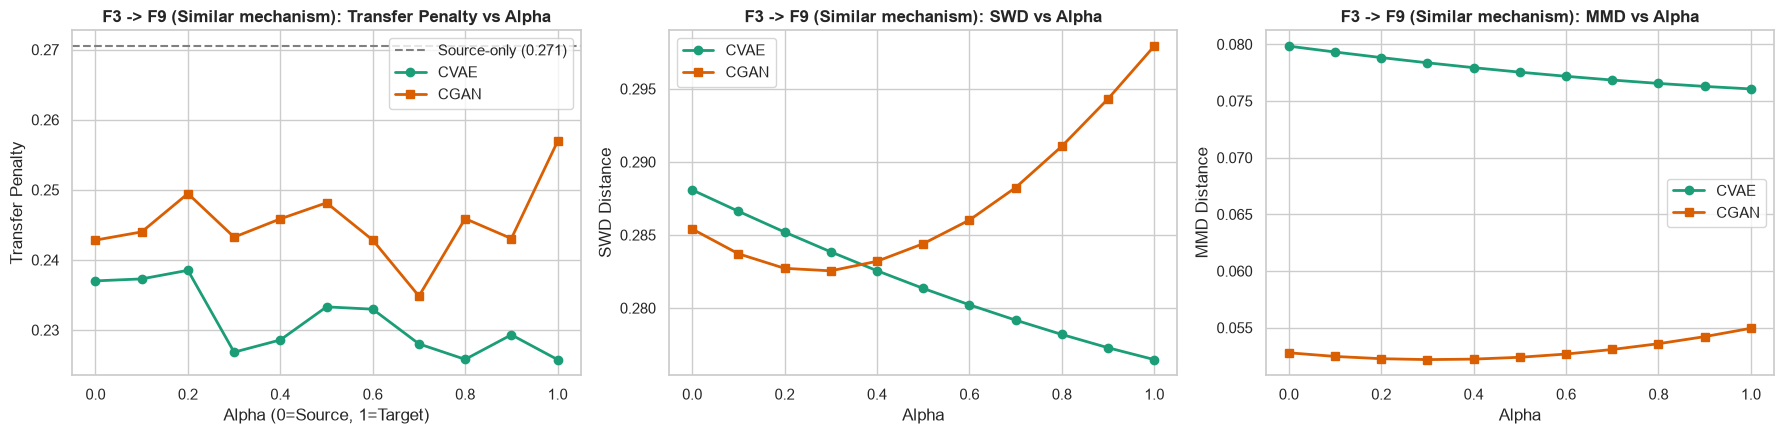


Processing Pair: F5 -> F15 (Same Subsystem)


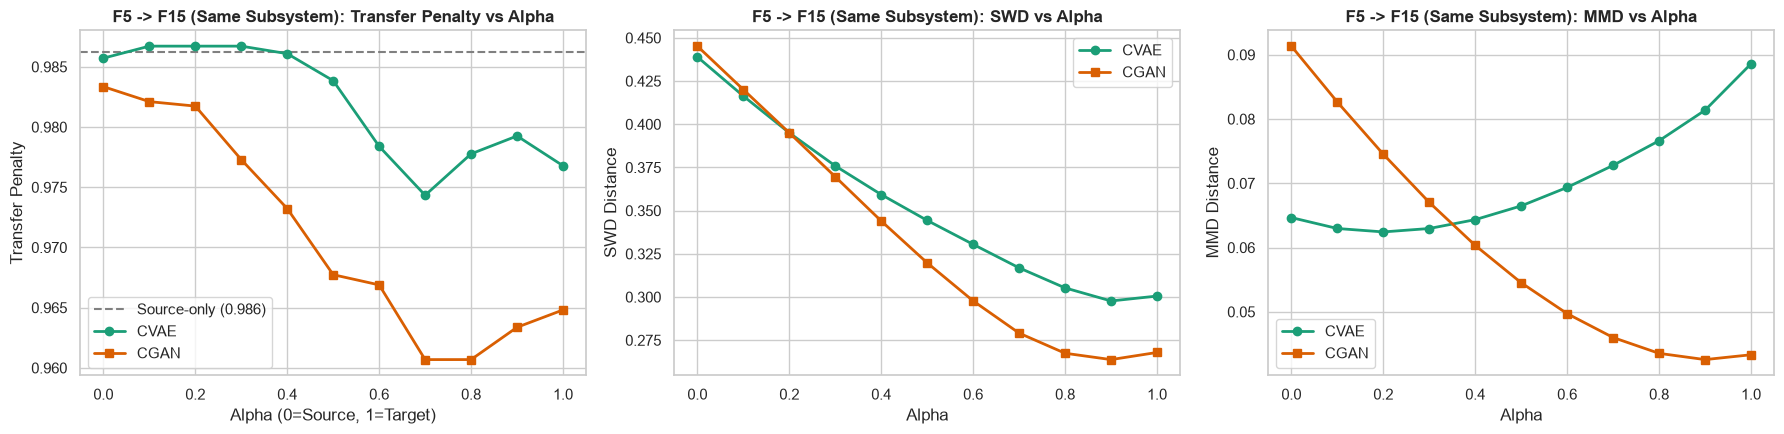


Processing Pair: F4 -> F13 (Unrelated Mechanism)


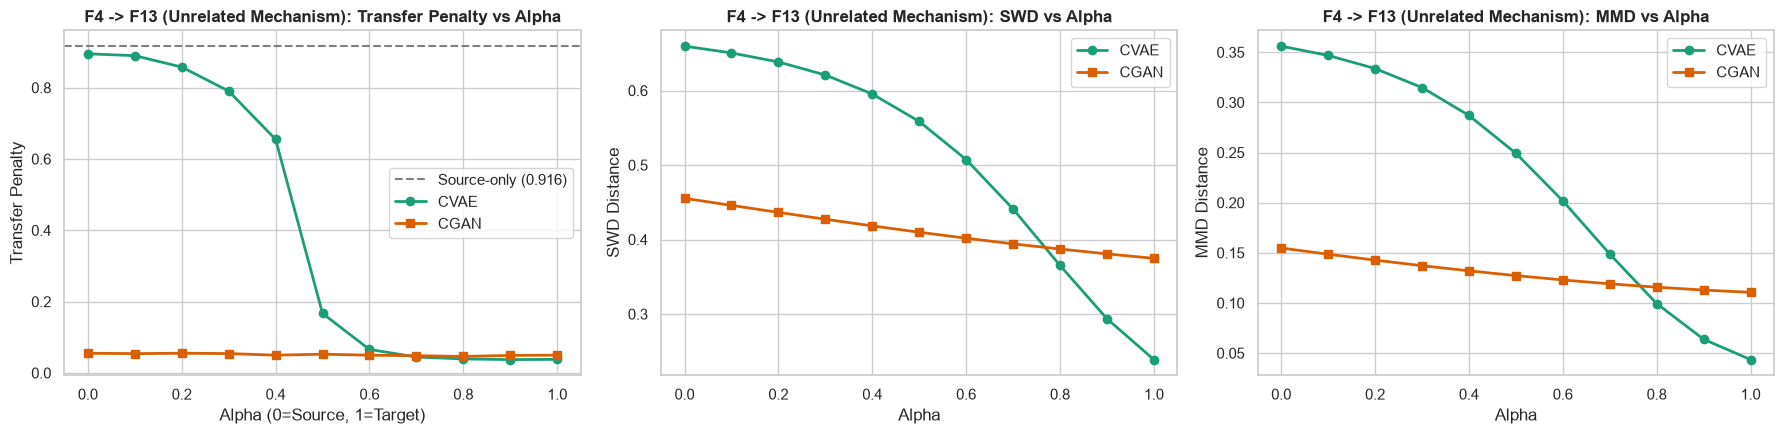


Processing Pair: F6 -> F15 (Unrelated mechanism)


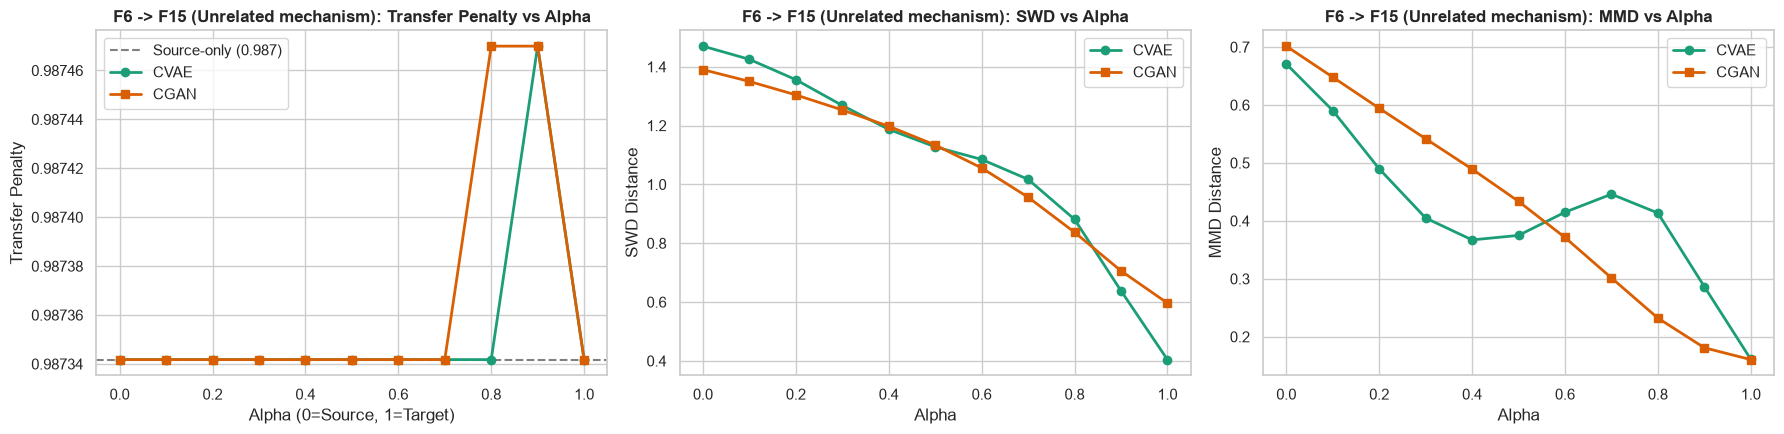

In [21]:
alphas = np.linspace(0.0, 1.0, 11)
N_SYNTHETIC = 500

for pair in REFERENCE_PAIRS:
    pair_name = pair['name']
    src_id = pair['source'][0] if isinstance(pair['source'], list) else pair['source']
    tgt_id = pair['target']
    print(f"\nProcessing Pair: {pair_name}")

    src_anom_tr = DOMAIN_FEATURES[src_id]['train']
    tgt_anom_tr = DOMAIN_FEATURES[tgt_id]['train']
    X_src_norm_tr = DOMAIN_FEATURES[0]['train']
    
    X_src_norm_te = DOMAIN_FEATURES[0]['test']
    src_anom_te = DOMAIN_FEATURES[src_id]['test']
    tgt_anom_te = DOMAIN_FEATURES[tgt_id]['test']
    
    X_source_train = np.vstack([X_src_norm_tr, src_anom_tr])
    y_source_train = np.concatenate([np.zeros(len(X_src_norm_tr)), np.ones(len(src_anom_tr))])


    X_source_test = np.vstack([X_src_norm_te, src_anom_te])
    y_source_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(src_anom_te))])
    
    X_tgt_test = np.vstack([X_src_norm_te, tgt_anom_te])
    y_tgt_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(tgt_anom_te))])

    all_tr_data = np.vstack([src_anom_tr, tgt_anom_tr])
    scaler = StandardScaler().fit(all_tr_data)
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)

    X_train_sc = scaler.transform(all_tr_data)
    c_train = np.concatenate([
        np.zeros((len(src_anom_tr), 1), dtype=np.float32),
        np.ones((len(tgt_anom_tr), 1), dtype=np.float32)
    ])

    X_source_train_sc = scaler.transform(X_source_train)
    X_source_test_sc  = scaler.transform(X_source_test)
    X_tgt_test_sc     = scaler.transform(X_tgt_test)
    tgt_scaled        = scaler.transform(tgt_anom_tr)

    set_seed(42)
    cvae = train_cvae(X_train_sc, c_train)
    set_seed(42)
    gen  = train_cgan(X_train_sc, c_train)

    rf0 = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
    rf0.fit(X_source_train_sc, y_source_train)
    
    src_baseline_f1 = f1_score(y_source_test, rf0.predict(X_source_test_sc), zero_division=0)
    tgt_baseline_f1 = f1_score(y_tgt_test, rf0.predict(X_tgt_test_sc), zero_division=0)
    noaug_penalty   = src_baseline_f1 - tgt_baseline_f1

    cvae_res, cgan_res = [], []
    for a in alphas:
        with torch.no_grad():
            c_vec = torch.full((N_SYNTHETIC, 1), float(a), device=DEVICE)

            set_seed(SEED)
            z_vec_vae = torch.randn(N_SYNTHETIC, LATENT_DIM, device=DEVICE)
            s_vae_sc = cvae.decode(z_vec_vae, c_vec).cpu().numpy()
            
            set_seed(SEED)
            z_vec_gan = torch.randn(N_SYNTHETIC, LATENT_DIM, device=DEVICE)
            s_gan_sc = gen(z_vec_gan, c_vec).cpu().numpy()

        for syn_sc, res_list in [(s_vae_sc, cvae_res), (s_gan_sc, cgan_res)]:
            X_bridged = np.vstack([X_source_train_sc, syn_sc])
            y_bridged = np.concatenate([y_source_train, np.ones(len(syn_sc))])
            
            rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
            rf.fit(X_bridged, y_bridged)
            
            bl_f1 = f1_score(y_source_test, rf.predict(X_source_test_sc), zero_division=0)
            tr_f1 = f1_score(y_tgt_test, rf.predict(X_tgt_test_sc), zero_division=0)
            
            dist = compute_distances(scaler.inverse_transform(syn_sc), tgt_anom_tr)
            res_list.append({
                'Alpha': round(a, 2),
                'Penalty': bl_f1 - tr_f1,
                'SWD': dist['SWD'],
                'MMD': dist['MMD'],
                'FD': dist['FD']
            })

    df_v = pd.DataFrame(cvae_res)
    df_g = pd.DataFrame(cgan_res)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    axes[0].axhline(noaug_penalty, color='gray', ls='--', lw=1.5, label=f'Source-only ({noaug_penalty:.3f})')
    axes[0].plot(df_v['Alpha'], df_v['Penalty'], 'o-', color='#1b9e77', lw=2, label='CVAE')
    axes[0].plot(df_g['Alpha'], df_g['Penalty'], 's-', color='#d95f02', lw=2, label='CGAN')
    axes[0].set_title(f'{pair_name}: Transfer Penalty vs Alpha', fontweight='bold')
    axes[0].set_xlabel('Alpha (0=Source, 1=Target)')
    axes[0].set_ylabel('Transfer Penalty')
    axes[0].legend()

    axes[1].plot(df_v['Alpha'], df_v['SWD'], 'o-', color='#1b9e77', lw=2, label='CVAE')
    axes[1].plot(df_g['Alpha'], df_g['SWD'], 's-', color='#d95f02', lw=2, label='CGAN')
    axes[1].set_title(f'{pair_name}: SWD vs Alpha', fontweight='bold')
    axes[1].set_xlabel('Alpha')
    axes[1].set_ylabel('SWD Distance')
    axes[1].legend()

    axes[2].plot(df_v['Alpha'], df_v['MMD'], 'o-', color='#1b9e77', lw=2, label='CVAE')
    axes[2].plot(df_g['Alpha'], df_g['MMD'], 's-', color='#d95f02', lw=2, label='CGAN')
    axes[2].set_title(f'{pair_name}: MMD vs Alpha', fontweight='bold')
    axes[2].set_xlabel('Alpha')
    axes[2].set_ylabel('MMD Distance')
    axes[2].legend()

    plt.tight_layout()
    plt.show()



Latent Space Evolution (All 208 Features): F3 -> F9 (Similar mechanism)


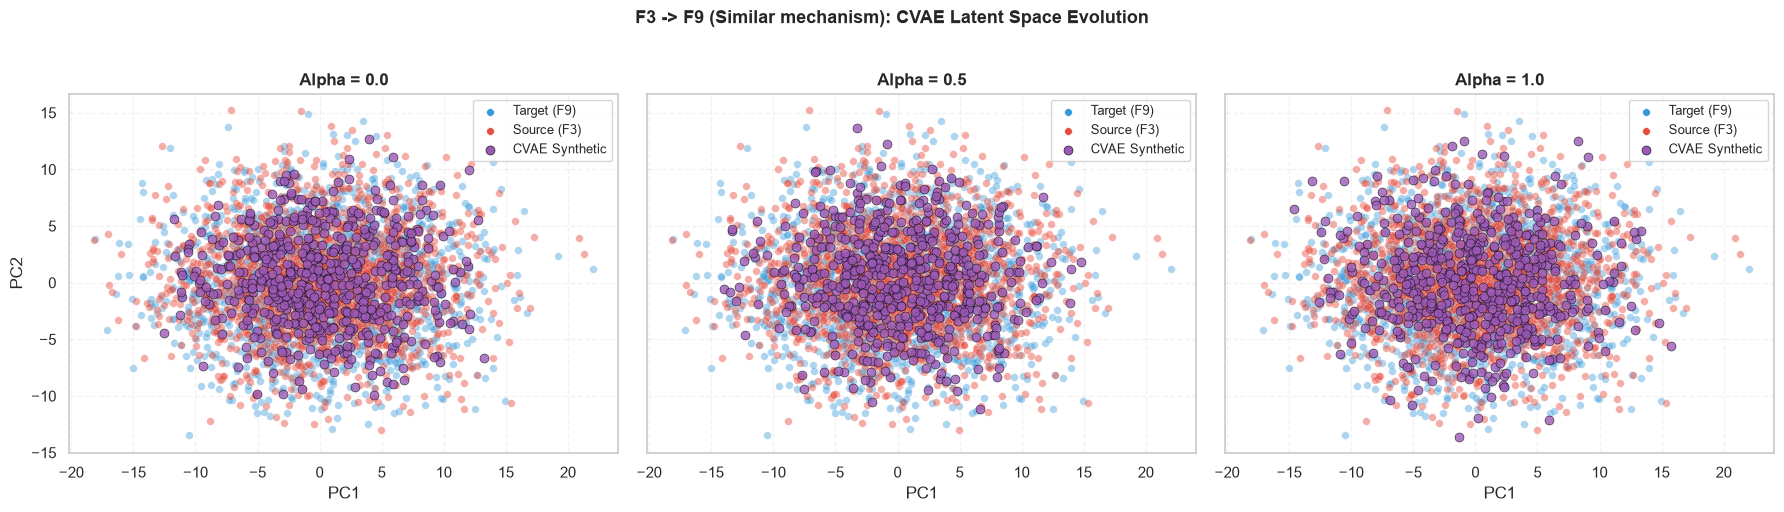

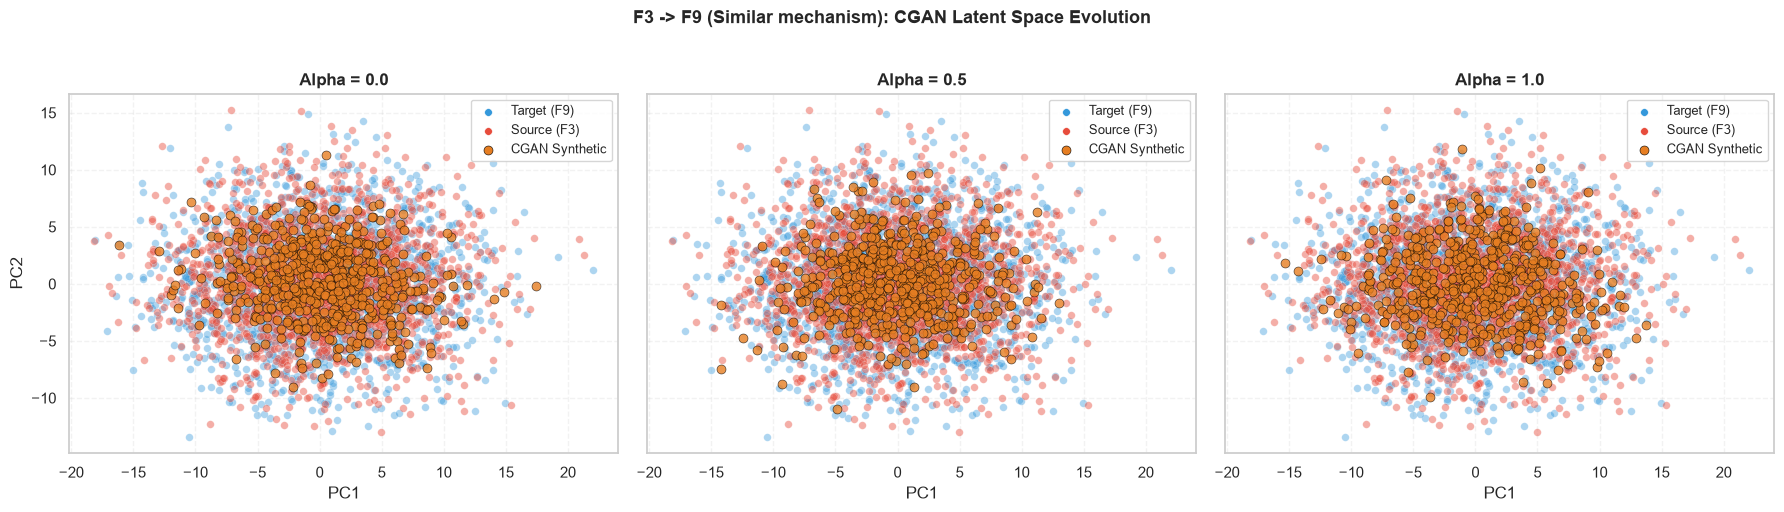


Latent Space Evolution (All 208 Features): F5 -> F15 (Same Subsystem)


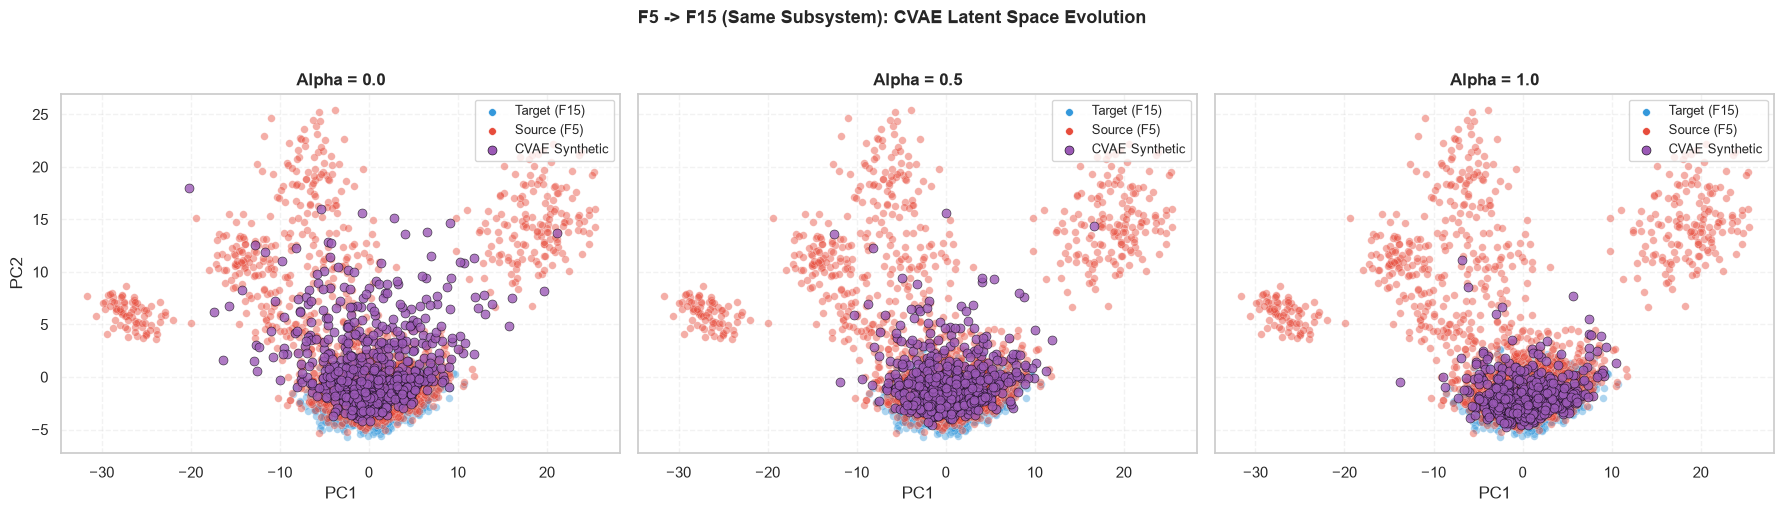

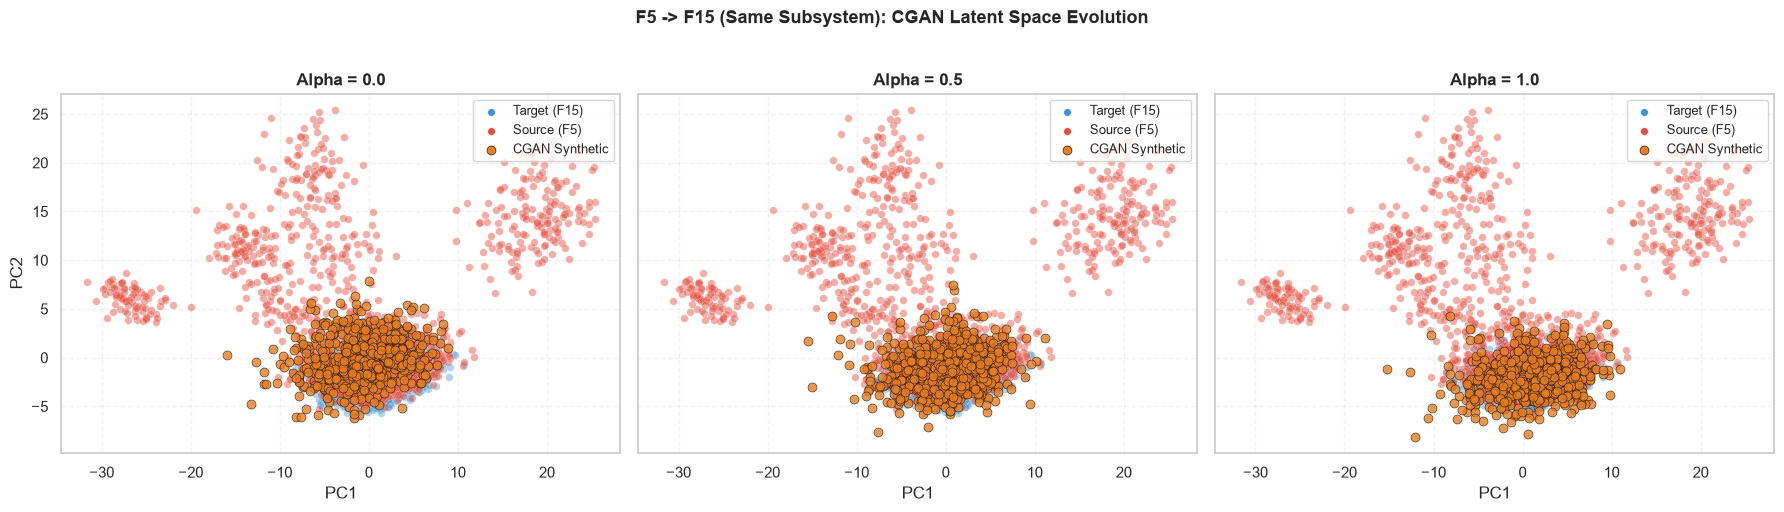


Latent Space Evolution (All 208 Features): F4 -> F13 (Unrelated Mechanism)


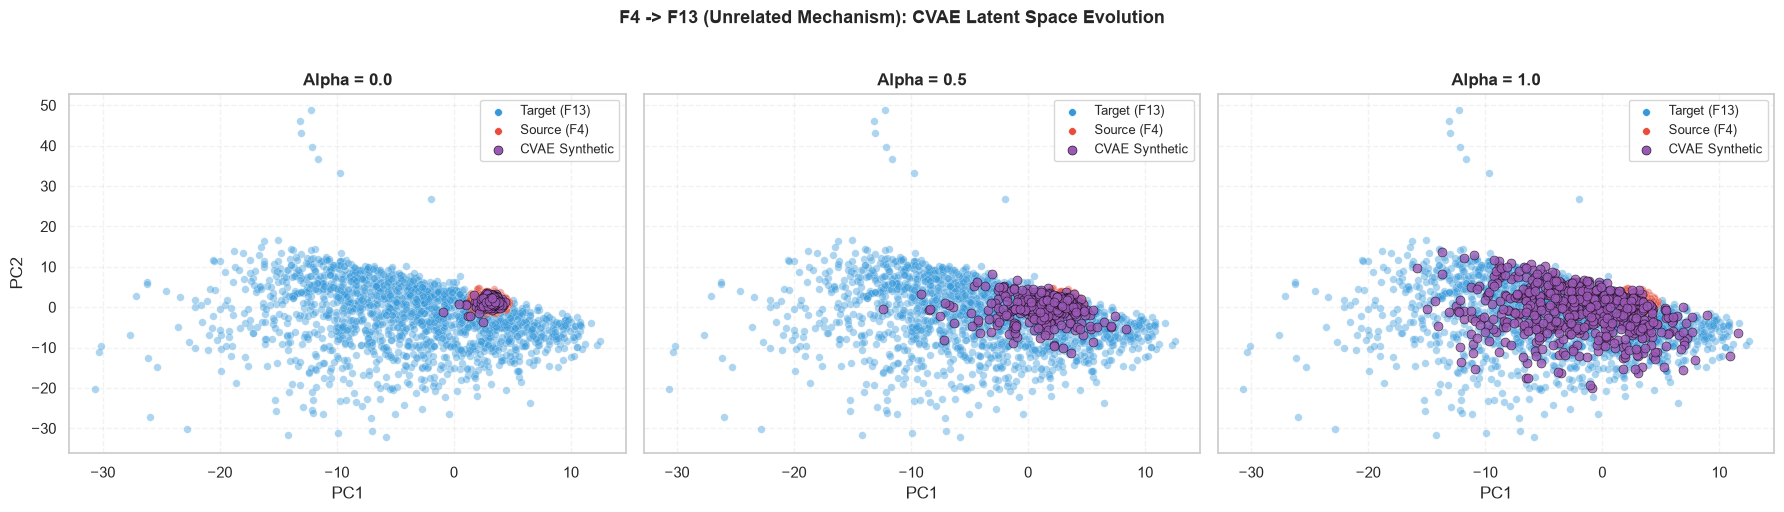

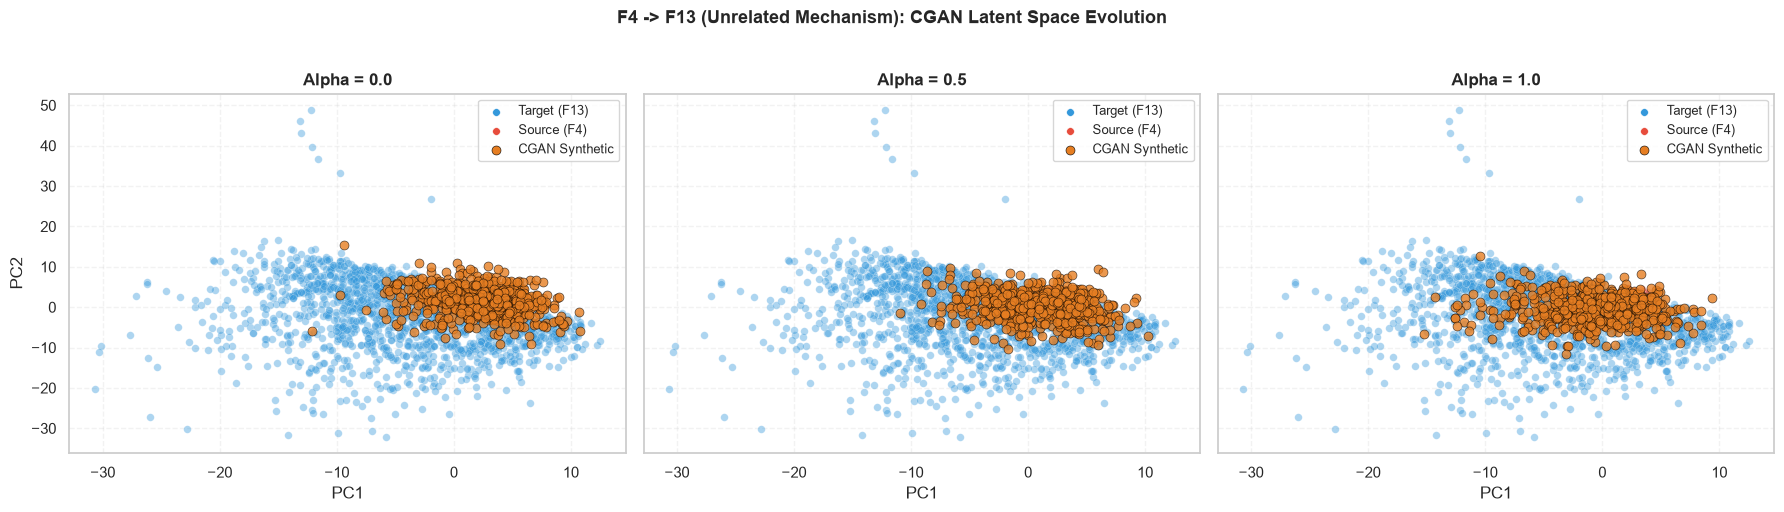


Latent Space Evolution (All 208 Features): F6 -> F15 (Unrelated mechanism)


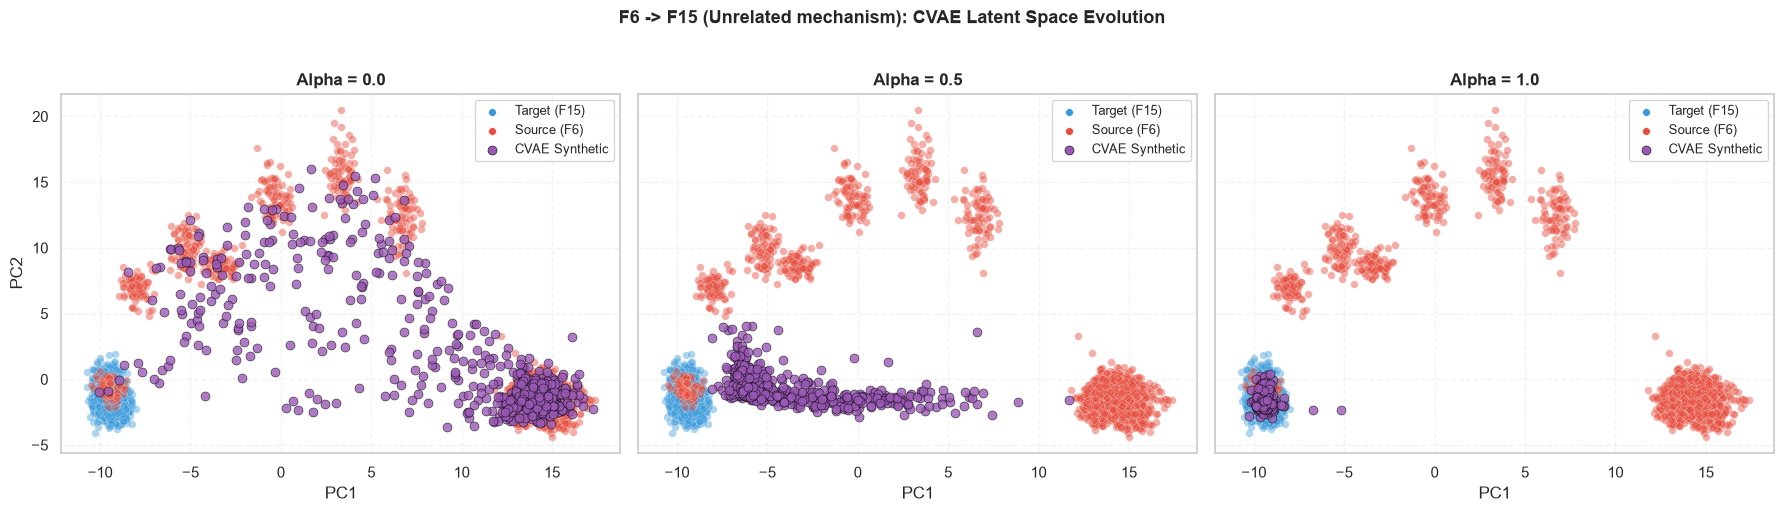

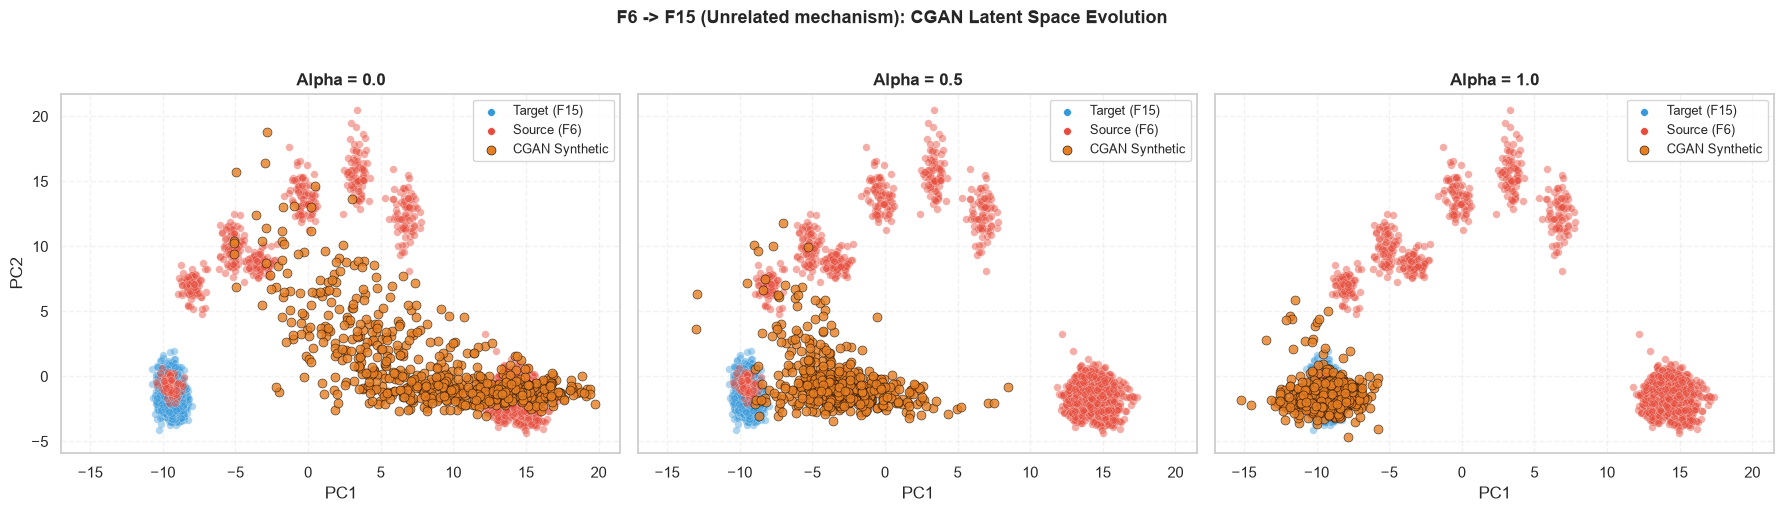

In [22]:
selected_alphas = [0.0, 0.5, 1.0]
COLOR_SRC, COLOR_TGT = '#e74c3c', '#3498db'
COLOR_CVAE, COLOR_CGAN = '#9b59b6', '#e67e22'


for pair in REFERENCE_PAIRS:
    pair_name = pair['name']
    src_id = pair['source'][0] if isinstance(pair['source'], list) else pair['source']
    tgt_id = pair['target']
    print(f"\nLatent Space Evolution (All 208 Features): {pair_name}")
    
    src_anom = DOMAIN_FEATURES[src_id]['train']
    tgt_anom = DOMAIN_FEATURES[tgt_id]['train']
    
    all_tr_data = np.vstack([src_anom, tgt_anom])
    scaler = StandardScaler().fit(all_tr_data)
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)
    
    X_train_sc = scaler.transform(all_tr_data)
    c_train = np.concatenate([
        np.zeros((len(src_anom), 1), dtype=np.float32),
        np.ones((len(tgt_anom), 1), dtype=np.float32)
    ])

    set_seed(SEED)
    cvae = train_cvae(X_train_sc, c_train)
    set_seed(SEED)
    gen  = train_cgan(X_train_sc, c_train)

    src_sc = scaler.transform(src_anom)
    tgt_sc = scaler.transform(tgt_anom)
    
    pca = PCA(n_components=2, random_state=SEED).fit(np.vstack([src_sc, tgt_sc]))
    src_2d = pca.transform(src_sc)
    tgt_2d = pca.transform(tgt_sc)

    for model_name, model, col in [('CVAE', cvae, COLOR_CVAE), ('CGAN', gen, COLOR_CGAN)]:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
        
        for idx, a in enumerate(selected_alphas):
            ax = axes[idx]
            with torch.no_grad():
                set_seed(SEED + idx)
                
                c_vec = torch.full((600, 1), float(a), device=DEVICE)
                z_vec = torch.randn(600, LATENT_DIM, device=DEVICE)
                
                syn_sc = model.decode(z_vec, c_vec).cpu().numpy() if model_name == 'CVAE' else model(z_vec, c_vec).cpu().numpy()
            
            syn_sc = np.clip(syn_sc, X_train_sc.min(axis=0) * 1.2, X_train_sc.max(axis=0) * 1.2)

            syn_2d = pca.transform(syn_sc)
            

            ax.scatter(tgt_2d[:, 0], tgt_2d[:, 1], alpha=0.40, c=COLOR_TGT, 
                       label=f'Target (F{tgt_id})', s=30, edgecolors='white', linewidth=0.3, zorder=1)
            
            ax.scatter(src_2d[:, 0], src_2d[:, 1], alpha=0.45, c=COLOR_SRC, 
                       label=f'Source (F{src_id})', s=30, edgecolors='white', linewidth=0.3, zorder=2)
            
            ax.scatter(syn_2d[:, 0], syn_2d[:, 1], alpha=0.80, c=col, 
                       label=f'{model_name} Synthetic', s=42, edgecolor='black', linewidth=0.4, zorder=3)
            
            ax.set_title(f'Alpha = {a}', fontweight='bold')
            ax.set_xlabel('PC1')
            if idx == 0: 
                ax.set_ylabel('PC2')
                
            leg = ax.legend(loc='upper right', fontsize=9)
            for handle in leg.legend_handles:
                handle.set_alpha(1.0)
                
            ax.grid(True, linestyle='--', alpha=0.25)

        plt.suptitle(f'{pair_name}: {model_name} Latent Space Evolution', fontweight='bold', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

This continuous domain interpolation evaluation across the four reference transfer tasks once again confirms that generative domain bridging is heavily dictated by physical subsystem alignment. For mechanistically similar and overlapping faults, such as $F3 \to F9$ and $F5 \to F15$, both SWD and MMD metrics decrease steadily as $\alpha \to 1.0$ for the CVAE, matching the PCA latent space projections. In these aligned regimes, CVAE augmentation drives the transfer penalty down to its lowest levels around $\alpha \approx 0.8$, whereas the CGAN exhibits a relatively flat trajectory or minor variations that fail to capture the optimal bridging manifold as effectively.In contrast, when attempting to bridge mechanically decoupled regimes like $F4 \to F13$, both generative models successfully decrease transfer penalties and geometric distances as $\alpha \to 1.0$, dropping close to zero at the boundary as synthetic samples approach the target domain support. However, in the extreme, fully disconnected failure mode $F6 \to F15$, the transfer penalty remains stubbornly flat near catastrophic ceiling levels ($\approx 0.967\text{--}0.987$) across the entire $\alpha$ sweep. While the CVAE attempts a linear interpolation between source and target clusters, the lack of shared underlying manifold geometry means that intermediate synthetic samples act as out-of-distribution noise rather than viable domain bridges, and the CGAN collapses entirely along the latent space projections without approaching the multimodal target modes.Overall, these results demonstrate that while generative interpolation can successfully bridge gaps when partial overlap or compatibility exists (such as in $F3 \to F9$, $F5 \to F15$, and $F4 \to F13$), neither architecture can synthesize a functional decision boundary across completely disjoint, unaligned failure modes like $F6 \to F15$ without genuine target guidance.

## 6. Few-Shot target budget scaling & generative augmentation: 4 core pairs

To evaluate whether synthetic generation can mitigate transfer penalties under limited target data availability, we implement a multi-volume few-shot augmentation protocol. For each of the reference domain pairs, we extract expanding target adaptation budgets representing fractions of the available training data (`TARGET_PERCENT_GRID = [2%, 6%, 12%, 20%]`), yielding $N$ real target samples. 

We benchmark the performance across seven distinct comparative scenarios: a source-only unaugmented baseline, a real-data few-shot baseline ($+N$ real target samples), and multi-volume synthetic expansions using both CVAE and CGAN generators at three scaling multipliers ($1\times, 5\times, \text{and } 10\times N$ synthetic samples). 
All target evaluation splits, target budget samples, and generated synthetic data are subsequently transformed using these fixed source distribution statistics. Furthermore, each generated batch is clipped within physical boundaries derived from the training margins and inverse-scaled back to raw feature space to prevent out-of-distribution distortion, tracking simultaneous metrics on Transfer Penalty (F1 drop) and distribution divergence ($\text{SWD}, \text{MMD}, \text{FD}$).

In [25]:

def eval_binary_rf(X_aug_raw: np.ndarray, y_aug: np.ndarray,
                   X_src_test_raw: np.ndarray, y_src_test: np.ndarray,
                   X_tgt_test_raw: np.ndarray, y_tgt_test: np.ndarray, fixed_scaler: StandardScaler = None,
                   fixed_baseline_f1: float = None) -> tuple[float, float, float]:
    """Evaluate Random Forest classifier on augmented domain features with exact Stage 2 parity.

    Fits a StandardScaler ONCE on the full training set (X_aug_raw) and transforms
    both the official source test split and frozen target test split.

    Args:
        X_aug_raw (np.ndarray): Augmented raw feature matrix (100% of train data).
        y_aug (np.ndarray): Augmented binary anomaly labels.
        X_src_test_raw (np.ndarray): Official held-out source test split.
        y_src_test (np.ndarray): Official source test labels.
        X_tgt_test_raw (np.ndarray): Frozen target test split.
        y_tgt_test (np.ndarray): Frozen target test labels.
        fixed_scaler (StandardScaler, optional): Pre-fitted StandardScaler. If None, fits on X_aug_raw.

    Returns:
        tuple[float, float, float]: Baseline F1, Transfer F1, and Transfer Penalty.
    """
   
    if fixed_scaler is None:
        fixed_scaler = StandardScaler().fit(X_aug_raw)
    X_tr_sc = fixed_scaler.transform(X_aug_raw)
    X_src_te_sc = fixed_scaler.transform(X_src_test_raw)
    X_tgt_te_sc = fixed_scaler.transform(X_tgt_test_raw)
    
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf.fit(X_tr_sc, y_aug)
    
    bl_f1 = f1_score(y_src_test, rf.predict(X_src_te_sc), zero_division=0)
    tr_f1 = f1_score(y_tgt_test, rf.predict(X_tgt_te_sc), zero_division=0)
    
    # CORREZIONE: Se fornito, usa l'F1 fisso del modello Source-Only iniziale
    baseline_ref = fixed_baseline_f1 if fixed_baseline_f1 is not None else bl_f1
    penalty = baseline_ref - tr_f1
    return bl_f1, tr_f1, penalty

In [39]:
TARGET_PERCENT_GRID = [0.02, 0.06, 0.12, 0.20]

binary_budget_records = []

for pair in REFERENCE_PAIRS:
    pair_name = pair['name']
    src_id = pair['source'][0] if isinstance(pair['source'], list) else pair['source']
    tgt_id = pair['target']

    print(f"\n\nPair = {pair_name},  Category = {pair['category']}")

    src_anom_tr = DOMAIN_FEATURES[src_id]['train']
    tgt_anom_tr = DOMAIN_FEATURES[tgt_id]['train']
    X_src_norm_tr = DOMAIN_FEATURES[0]['train']

    X_src_norm_te = DOMAIN_FEATURES[0]['test']
    src_anom_te = DOMAIN_FEATURES[src_id]['test']
    tgt_anom_te = DOMAIN_FEATURES[tgt_id]['test']

    X_source_train = np.vstack([X_src_norm_tr, src_anom_tr])
    y_source_train = np.concatenate([np.zeros(len(X_src_norm_tr)), np.ones(len(src_anom_tr))])

    X_source_test = np.vstack([X_src_norm_te, src_anom_te])
    y_source_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(src_anom_te))])

    X_tgt_test = np.vstack([X_src_norm_te, tgt_anom_te])
    y_tgt_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(tgt_anom_te))])


    fixed_scaler = StandardScaler().fit(X_source_train)
    fixed_scaler.scale_ = np.maximum(fixed_scaler.scale_, 1e-3)
    
    pre_dist = compute_distances(src_anom_tr, tgt_anom_tr)
    

    src_f1, tr_src, pen_src = eval_binary_rf(
        X_source_train,
        y_source_train,
        X_source_test,
        y_source_test,
        X_tgt_test,
        y_tgt_test,
        fixed_scaler=fixed_scaler
    )
    
    print(f"\nScenario 1: Source-Only (Baseline) | SWD = {pre_dist['SWD']:.4f} | MMD = {pre_dist['MMD']:.4f}| FD = {pre_dist['FD']:.4f} | Source F1 = {src_f1:.4f} | Target F1 = {tr_src:.4f} | Penalty = {pen_src:.4f}")
    
    for pct in TARGET_PERCENT_GRID:
        total_tgt_train = len(tgt_anom_tr)
        N = max(10, int(np.round(pct * total_tgt_train)))
        set_seed(SEED)
        rng = np.random.default_rng(SEED)
        idx = rng.choice(total_tgt_train, N, replace=False)
        tgt_budget_anom = tgt_anom_tr[idx]

        X_real_raw = np.vstack([X_source_train, tgt_budget_anom])
        y_real = np.concatenate([y_source_train, np.ones(N)])
        src_f1_real, tr_real, pen_real = eval_binary_rf(
        X_real_raw,
        y_real,
        X_source_test,
        y_source_test,
        X_tgt_test,
        y_tgt_test,
        fixed_scaler=fixed_scaler,
        fixed_baseline_f1=tr_src 
    )
        dist_real = compute_distances(tgt_budget_anom, tgt_anom_tr)
        print(f"\nScenario 2: Real N={N} ({int(pct*100)}%) | SWD = {dist_real['SWD']:.4f} | MMD = {dist_real['MMD']:.4f}| FD = {dist_real['FD']:.4f} | Source F1 = {src_f1_real:.4f} | Target F1 = {tr_real:.4f} | Penalty = {pen_real:.4f} ")


        sub_tr_data = np.vstack([src_anom_tr, tgt_budget_anom])
        sub_scaler = StandardScaler().fit(sub_tr_data)
        sub_scaler.scale_ = np.maximum(sub_scaler.scale_, 1e-3)

        X_sub_tr_sc = sub_scaler.transform(sub_tr_data)
        c_sub_tr = np.concatenate([
            np.zeros((len(src_anom_tr), 1), dtype=np.float32),
            np.ones((len(tgt_budget_anom), 1), dtype=np.float32)
        ])

        margin = 0.20 * (sub_tr_data.max(axis=0) - sub_tr_data.min(axis=0))
        lower_bound = sub_scaler.transform((sub_tr_data.min(axis=0) - margin).reshape(1, -1)).squeeze()
        upper_bound = sub_scaler.transform((sub_tr_data.max(axis=0) + margin).reshape(1, -1)).squeeze()

        set_seed(SEED)
        cvae = train_cvae(X_sub_tr_sc, c_sub_tr)
        set_seed(SEED)
        gen  = train_cgan(X_sub_tr_sc, c_sub_tr)

        # Multi-Volume Synthetic Generation for CVAE and CGAN (1x N, 5x N, 10x N)
        syn_dict_raw = {}
        for model_name, model_obj in [('CVAE', cvae), ('CGAN', gen)]:
            for mult in [1, 5, 10]:
                n_gen = mult * N
                with torch.no_grad():
                    set_seed(SEED + mult)
                    c_vec = torch.ones((n_gen, 1), device=DEVICE)

                    if model_name == 'CVAE':
                        z_vec = torch.randn(n_gen, LATENT_DIM, device=DEVICE)
                        syn_sc = cvae.decode(z_vec, c_vec).cpu().numpy()
                    else:
                        z_vec = torch.randn(n_gen, LATENT_DIM, device=DEVICE)
                        syn_sc = model_obj(z_vec, c_vec).cpu().numpy()

                    syn_sc = np.clip(syn_sc, lower_bound, upper_bound)
                    syn_dict_raw[f'{model_name}_{mult}x'] = sub_scaler.inverse_transform(syn_sc)

        # Generative Evaluation Scenarios (CVAE 1x, 5x, 10x and CGAN 1x, 5x, 10x)
        eval_gen_res = {}
        for key, syn_raw in syn_dict_raw.items():
            X_bridged_raw = np.vstack([X_source_train, syn_raw])
            y_bridged = np.concatenate([y_source_train, np.ones(len(syn_raw))])

            src_f1, tr_f1, pen = eval_binary_rf(
                X_bridged_raw,
                y_bridged,
                X_source_test,
                y_source_test,
                X_tgt_test,
                y_tgt_test,
                fixed_scaler=fixed_scaler,
                fixed_baseline_f1=tr_src ,
            )
            dist = compute_distances(syn_raw, tgt_anom_tr)

            eval_gen_res[key] = {
                'src_f1': src_f1, 'tr_f1': tr_f1, 'penalty': pen,
                'SWD': dist['SWD'], 'MMD': dist['MMD'], 'FD': dist['FD']
            }
            
        # Scenario 3: 1x Synthetic Data (Volume = N)
        print(f"\nScenario 3: Generative Models with 1x Synthetic Data (N={N})")
        print(f"CVAE 1x | SWD = {eval_gen_res['CVAE_1x']['SWD']:.4f} | MMD = {eval_gen_res['CVAE_1x']['MMD']:.4f} | FD = {eval_gen_res['CVAE_1x']['FD']:.4f} | Source F1 = {eval_gen_res['CVAE_1x']['src_f1']:.4f} | Target F1 = {eval_gen_res['CVAE_1x']['tr_f1']:.4f} | Penalty = {eval_gen_res['CVAE_1x']['penalty']:.4f}")
        print(f"CGAN 1x | SWD = {eval_gen_res['CGAN_1x']['SWD']:.4f} | MMD = {eval_gen_res['CGAN_1x']['MMD']:.4f} | FD = {eval_gen_res['CGAN_1x']['FD']:.4f} | Source F1 = {eval_gen_res['CGAN_1x']['src_f1']:.4f} | Target F1 = {eval_gen_res['CGAN_1x']['tr_f1']:.4f} | Penalty = {eval_gen_res['CGAN_1x']['penalty']:.4f}")

        # Scenario 4: 5x Synthetic Data (Volume = 5*N)
        print(f"\nScenario 4: Generative Models with 5x Synthetic Data (5*N={5*N})")
        print(f"CVAE 5x | SWD = {eval_gen_res['CVAE_5x']['SWD']:.4f} | MMD = {eval_gen_res['CVAE_5x']['MMD']:.4f} | FD = {eval_gen_res['CVAE_5x']['FD']:.4f} | Source F1 = {eval_gen_res['CVAE_5x']['src_f1']:.4f} | Target F1 = {eval_gen_res['CVAE_5x']['tr_f1']:.4f} | Penalty = {eval_gen_res['CVAE_5x']['penalty']:.4f}")
        print(f"CGAN 5x | SWD = {eval_gen_res['CGAN_5x']['SWD']:.4f} | MMD = {eval_gen_res['CGAN_5x']['MMD']:.4f} | FD = {eval_gen_res['CGAN_5x']['FD']:.4f} | Source F1 = {eval_gen_res['CGAN_5x']['src_f1']:.4f} | Target F1 = {eval_gen_res['CGAN_5x']['tr_f1']:.4f} | Penalty = {eval_gen_res['CGAN_5x']['penalty']:.4f}")

        # Scenario 5: 10x Synthetic Data (Volume = 10*N)
        print(f"\nScenario 5: Generative Models with 10x Synthetic Data (10*N={10*N})")
        print(f"CVAE 10x | SWD = {eval_gen_res['CVAE_10x']['SWD']:.4f} | MMD = {eval_gen_res['CVAE_10x']['MMD']:.4f} | FD = {eval_gen_res['CVAE_10x']['FD']:.4f} | Source F1 = {eval_gen_res['CVAE_10x']['src_f1']:.4f} | Target F1 = {eval_gen_res['CVAE_10x']['tr_f1']:.4f} | Penalty = {eval_gen_res['CVAE_10x']['penalty']:.4f}")
        print(f"CGAN 10x | SWD = {eval_gen_res['CGAN_10x']['SWD']:.4f} | MMD = {eval_gen_res['CGAN_10x']['MMD']:.4f} | FD = {eval_gen_res['CGAN_10x']['FD']:.4f} | Source F1 = {eval_gen_res['CGAN_10x']['src_f1']:.4f} | Target F1 = {eval_gen_res['CGAN_10x']['tr_f1']:.4f} | Penalty = {eval_gen_res['CGAN_10x']['penalty']:.4f}")
       
        binary_budget_records.append({
            'Pair': pair_name, 'Category': pair['category'], 'Percent': pct * 100, 'N': N,
            'Pre_SWD': pre_dist['SWD'], 'Pre_MMD': pre_dist['MMD'], 'Pre_FD': pre_dist['FD'],

            # Scenario 1: Source only
            'F1_Source_Only': tr_src, 'Penalty_Source_Only': pen_src,

            # Scenario 2: Real N
            'F1_Real_N': tr_real, 'Penalty_Real_N': pen_real, 'SWD_Real_N': dist_real['SWD'], 'MMD_Real_N': dist_real['MMD'], 'FD_Real_N': dist_real['FD'],

            # CVAE Multi-Volume
            'F1_CVAE_1x': eval_gen_res['CVAE_1x']['tr_f1'], 'Penalty_CVAE_1x': eval_gen_res['CVAE_1x']['penalty'], 'SWD_CVAE_1x': eval_gen_res['CVAE_1x']['SWD'], 'MMD_CVAE_1x': eval_gen_res['CVAE_1x']['MMD'], 'FD_CVAE_1x': eval_gen_res['CVAE_1x']['FD'],
            'F1_CVAE_5x': eval_gen_res['CVAE_5x']['tr_f1'], 'Penalty_CVAE_5x': eval_gen_res['CVAE_5x']['penalty'], 'SWD_CVAE_5x': eval_gen_res['CVAE_5x']['SWD'], 'MMD_CVAE_5x': eval_gen_res['CVAE_5x']['MMD'], 'FD_CVAE_5x': eval_gen_res['CVAE_5x']['FD'],
            'F1_CVAE_10x': eval_gen_res['CVAE_10x']['tr_f1'], 'Penalty_CVAE_10x': eval_gen_res['CVAE_10x']['penalty'], 'SWD_CVAE_10x': eval_gen_res['CVAE_10x']['SWD'], 'MMD_CVAE_10x': eval_gen_res['CVAE_10x']['MMD'], 'FD_CVAE_10x': eval_gen_res['CVAE_10x']['FD'],

            # CGAN Multi-Volume
            'F1_CGAN_1x': eval_gen_res['CGAN_1x']['tr_f1'], 'Penalty_CGAN_1x': eval_gen_res['CGAN_1x']['penalty'], 'SWD_CGAN_1x': eval_gen_res['CGAN_1x']['SWD'], 'MMD_CGAN_1x': eval_gen_res['CGAN_1x']['MMD'], 'FD_CGAN_1x': eval_gen_res['CGAN_1x']['FD'],
            'F1_CGAN_5x': eval_gen_res['CGAN_5x']['tr_f1'], 'Penalty_CGAN_5x': eval_gen_res['CGAN_5x']['penalty'], 'SWD_CGAN_5x': eval_gen_res['CGAN_5x']['SWD'], 'MMD_CGAN_5x': eval_gen_res['CGAN_5x']['MMD'], 'FD_CGAN_5x': eval_gen_res['CGAN_5x']['FD'],
            'F1_CGAN_10x': eval_gen_res['CGAN_10x']['tr_f1'], 'Penalty_CGAN_10x': eval_gen_res['CGAN_10x']['penalty'], 'SWD_CGAN_10x': eval_gen_res['CGAN_10x']['SWD'], 'MMD_CGAN_10x': eval_gen_res['CGAN_10x']['MMD'], 'FD_CGAN_10x': eval_gen_res['CGAN_10x']['FD'],

            'Gain_CVAE_1x': eval_gen_res['CVAE_1x']['tr_f1'] - tr_src,
            'Gain_CVAE_5x': eval_gen_res['CVAE_5x']['tr_f1'] - tr_src,
            'Gain_CVAE_10x': eval_gen_res['CVAE_10x']['tr_f1'] - tr_src,
            'Gain_CGAN_1x': eval_gen_res['CGAN_1x']['tr_f1'] - tr_src,
            'Gain_CGAN_5x': eval_gen_res['CGAN_5x']['tr_f1'] - tr_src,
            'Gain_CGAN_10x': eval_gen_res['CGAN_10x']['tr_f1'] - tr_src,
        })

df_binary_budget = pd.DataFrame(binary_budget_records)

summary_5_scenarios = df_binary_budget.groupby('Percent').agg({
    'N': 'mean',
    'F1_Source_Only': 'mean',
    'F1_Real_N': 'mean',
    'F1_CVAE_1x': 'mean',
    'F1_CVAE_5x': 'mean',
    'F1_CVAE_10x': 'mean',
    'F1_CGAN_1x': 'mean',
    'F1_CGAN_5x': 'mean',
    'F1_CGAN_10x': 'mean',
    'SWD_Real_N': 'mean',
    'SWD_CVAE_1x': 'mean',
    'SWD_CVAE_5x': 'mean',
    'SWD_CVAE_10x': 'mean',
    'SWD_CGAN_1x': 'mean',
    'SWD_CGAN_5x': 'mean',
    'SWD_CGAN_10x': 'mean',
}).reset_index()

display(summary_5_scenarios.round(4))




Pair = F3 -> F9 (Similar mechanism),  Category = Similar mechanism

Scenario 1: Source-Only (Baseline) | SWD = 0.0659 | MMD = 0.0018| FD = 1.3888 | Source F1 = 0.6698 | Target F1 = 0.3994 | Penalty = 0.2704

Scenario 2: Real N=38 (2%) | SWD = 0.1968 | MMD = 0.0215| FD = 115.2045 | Source F1 = 0.6722 | Target F1 = 0.3967 | Penalty = 0.0027 

Scenario 3: Generative Models with 1x Synthetic Data (N=38)
CVAE 1x | SWD = 0.3196 | MMD = 0.0943 | FD = 92.0444 | Source F1 = 0.6699 | Target F1 = 0.4070 | Penalty = -0.0075
CGAN 1x | SWD = 0.4234 | MMD = 0.1471 | FD = 160.6341 | Source F1 = 0.6740 | Target F1 = 0.4092 | Penalty = -0.0097

Scenario 4: Generative Models with 5x Synthetic Data (5*N=190)
CVAE 5x | SWD = 0.3049 | MMD = 0.0862 | FD = 77.4145 | Source F1 = 0.6797 | Target F1 = 0.4212 | Penalty = -0.0218
CGAN 5x | SWD = 0.3752 | MMD = 0.1299 | FD = 152.4315 | Source F1 = 0.6746 | Target F1 = 0.4148 | Penalty = -0.0154

Scenario 5: Generative Models with 10x Synthetic Data (10*N=380)
CVA

,Percent,N,F1_Source_Only,F1_Real_N,F1_CVAE_1x,F1_CVAE_5x,F1_CVAE_10x,F1_CGAN_1x,F1_CGAN_5x,F1_CGAN_10x,SWD_Real_N,SWD_CVAE_1x,SWD_CVAE_5x,SWD_CVAE_10x,SWD_CGAN_1x,SWD_CGAN_5x,SWD_CGAN_10x
0,2.0,38.0,0.1211,0.3316,0.1274,0.1468,0.1502,0.1212,0.1236,0.1294,0.2063,1.2689,0.8314,0.7202,1.4628,0.9139,0.7906
1,6.0,115.0,0.1211,0.3425,0.2292,0.2658,0.2889,0.1310,0.1336,0.1393,0.1137,0.7710,0.5894,0.5591,1.0213,0.7330,0.6837
2,12.0,230.0,0.1211,0.3531,0.3465,0.3576,0.3581,0.1351,0.1388,0.1459,0.0772,0.5764,0.4943,0.5056,0.8404,0.6607,0.6609
3,20.0,384.0,0.1211,0.3693,0.3491,0.3541,0.3603,0.1429,0.1527,0.1633,0.0560,0.4179,0.4198,0.4554,0.6554,0.5596,0.5817


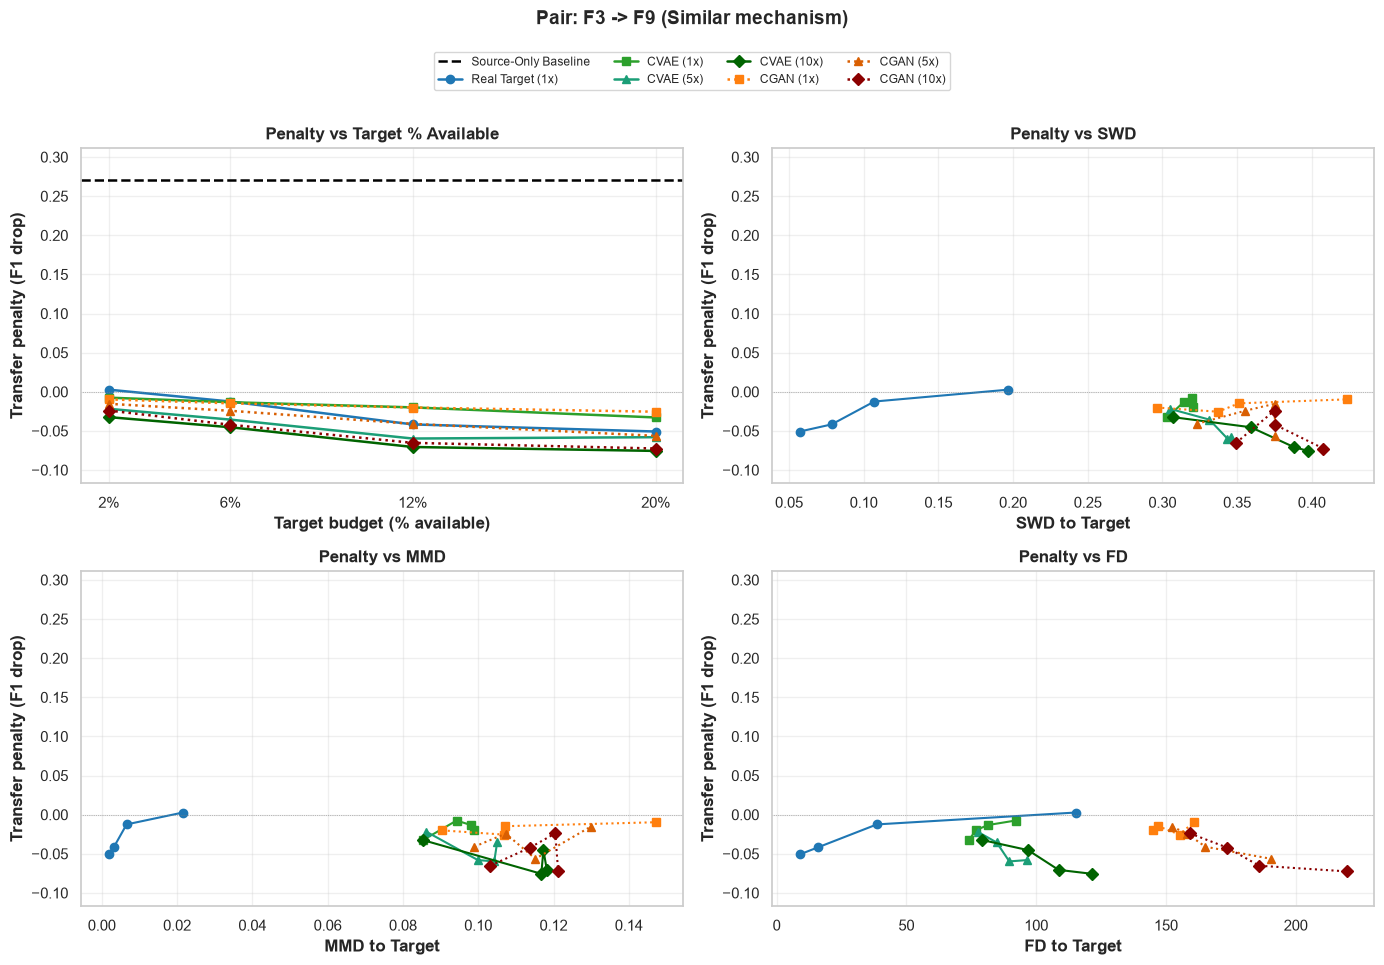

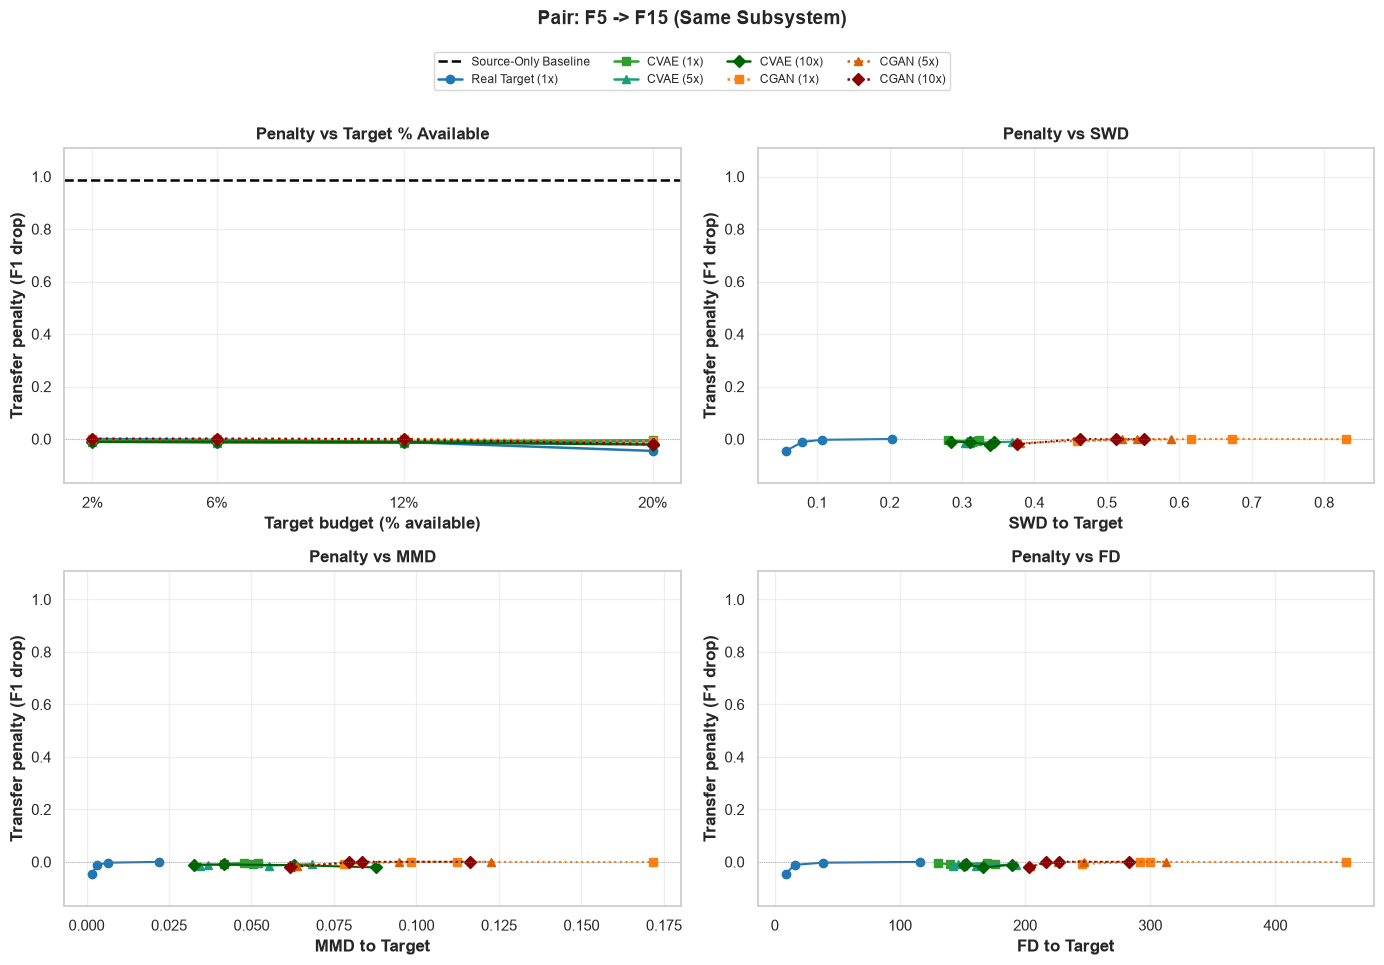

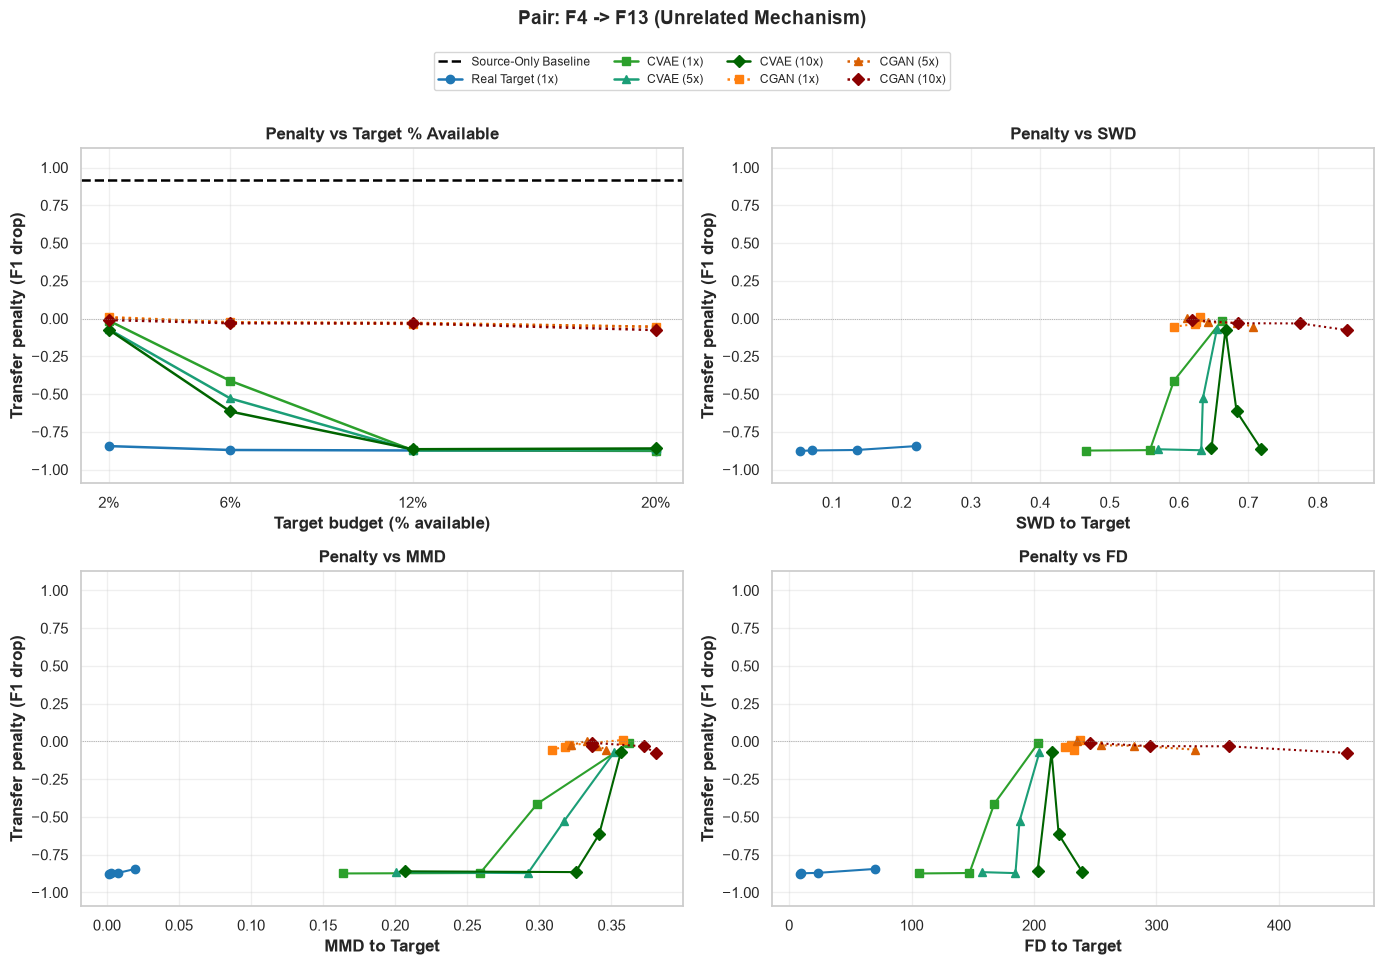

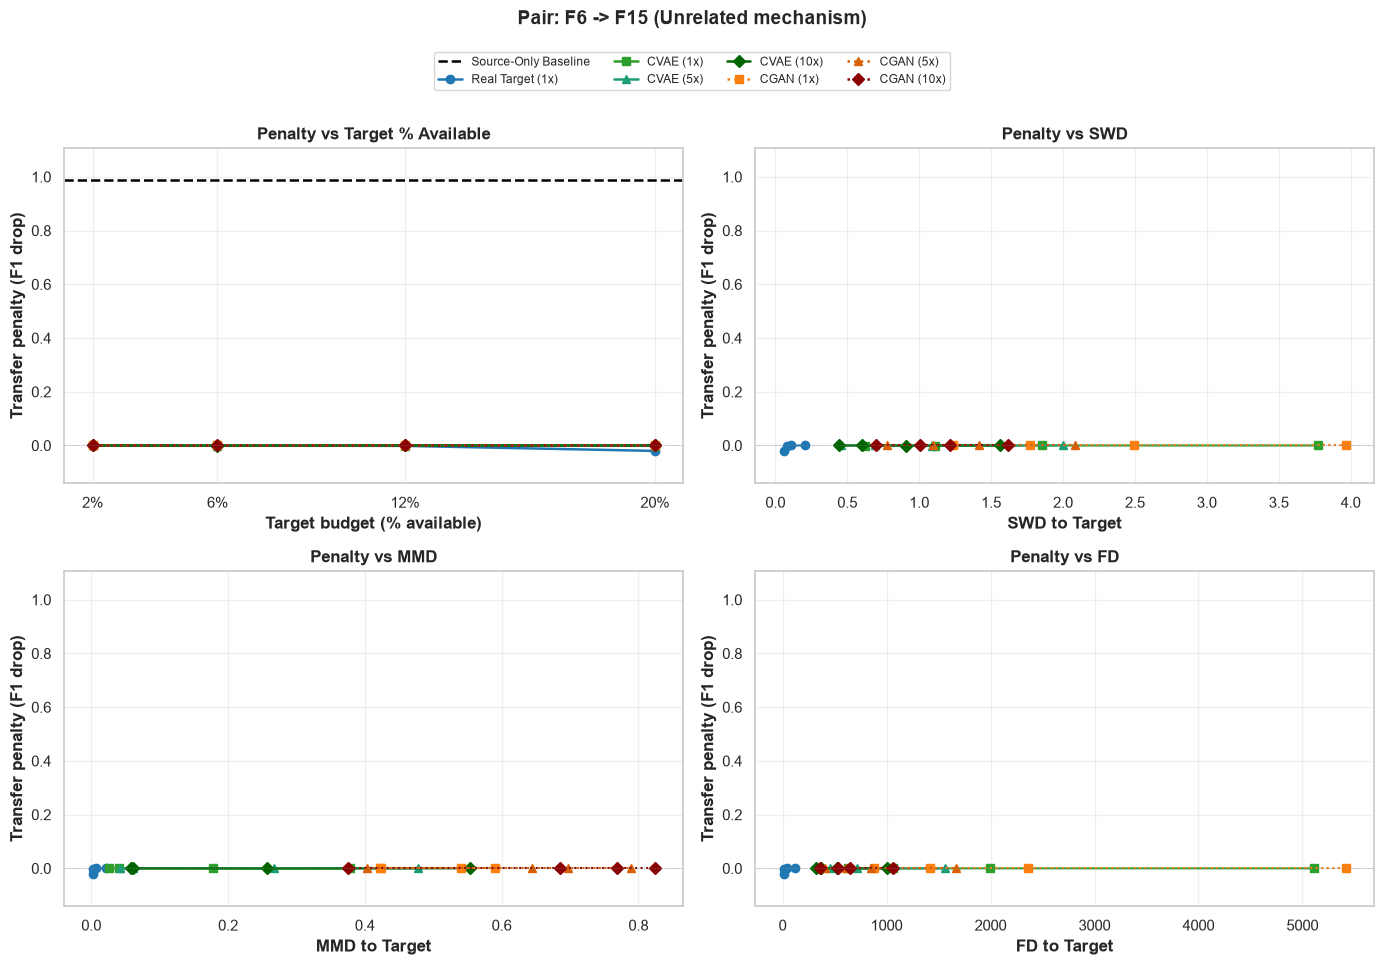

In [41]:
STYLES = {
    'Real_N':    {'color': '#1f77b4', 'ls': '-',  'marker': 'o', 'label': 'Real Target (1x)'},
    'CVAE_1x':   {'color': '#2ca02c', 'ls': '-',  'marker': 's', 'label': 'CVAE (1x)'},
    'CVAE_5x':   {'color': '#1b9e77', 'ls': '-',  'marker': '^', 'label': 'CVAE (5x)'},
    'CVAE_10x':  {'color': '#006400', 'ls': '-',  'marker': 'D', 'label': 'CVAE (10x)'},
    'CGAN_1x':   {'color': '#ff7f0e', 'ls': ':',  'marker': 's', 'label': 'CGAN (1x)'},
    'CGAN_5x':   {'color': '#d95f02', 'ls': ':',  'marker': '^', 'label': 'CGAN (5x)'},
    'CGAN_10x':  {'color': '#8b0000', 'ls': ':',  'marker': 'D', 'label': 'CGAN (10x)'},
}

def plot_distance_panel(ax, tbl, metric_name):
    """Panel for the metrics of distance (SWD, MMD, FD) vs Transfer Penalty."""
    src_pen = tbl['Penalty_Source_Only'].iloc[0]
    
    for scen_key, style in STYLES.items():
        col_dist = f'{metric_name}_{scen_key}'
        col_pen  = f'Penalty_{scen_key}'
        
        if col_dist in tbl.columns and col_pen in tbl.columns:
            s = tbl.sort_values(col_dist)
            ax.plot(s[col_dist], s[col_pen], label=style['label'], color=style['color'], 
                    ls=style['ls'], marker=style['marker'], lw=1.5)

    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel(f'{metric_name} to Target', fontweight='bold')
    ax.set_ylabel('Transfer penalty (F1 drop)', fontweight='bold')
    ax.set_title(f'Penalty vs {metric_name}', fontweight='bold')
    ax.grid(True, alpha=0.3)


def plot_pair_budget(pair_name, tbl):
    """Generates a 2x2 grid for a single fault pair."""
    src_pen_val = tbl['Penalty_Source_Only'].iloc[0]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    ax_pct = axes[0, 0]
    ax_pct.axhline(src_pen_val, color='black', ls='--', lw=1.8, label='Source-Only Baseline')

    for scen_key, style in STYLES.items():
        col_pen = f'Penalty_{scen_key}'
        if col_pen in tbl.columns:
            s = tbl.sort_values('Percent')
            ax_pct.plot(s['Percent'], s[col_pen], label=style['label'], color=style['color'], 
                        ls=style['ls'], marker=style['marker'], lw=1.8)

    ax_pct.axhline(0, color='gray', lw=0.5, ls=':')
    ax_pct.set_xlabel('Target budget (% available)', fontweight='bold')
    ax_pct.set_ylabel('Transfer penalty (F1 drop)', fontweight='bold')
    ax_pct.set_title('Penalty vs Target % Available', fontweight='bold')
    ax_pct.set_xticks([2, 6, 12, 20])
    ax_pct.set_xticklabels(['2%', '6%', '12%', '20%'])
    ax_pct.grid(True, alpha=0.3)

    plot_distance_panel(axes[0, 1], tbl, 'SWD')
    plot_distance_panel(axes[1, 0], tbl, 'MMD')
    plot_distance_panel(axes[1, 1], tbl, 'FD')

    all_pen_cols = [c for c in tbl.columns if c.startswith('Penalty_')]
    y_vals = tbl[all_pen_cols].values.flatten()
    y_vals = y_vals[~np.isnan(y_vals)]
    y_min, y_max = np.min(y_vals), np.max(y_vals)
    pad_y = (y_max - y_min) * 0.12 if y_max != y_min else 0.05
    
    for ax in axes.flat:
        ax.set_ylim(y_min - pad_y, y_max + pad_y)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=4, fontsize=8.5, frameon=True)

    fig.suptitle(f'Pair: {pair_name}', fontsize=14, fontweight='bold', y=1.07)
    plt.tight_layout()
    plt.show()

for pair_name in df_binary_budget['Pair'].unique():
    tbl_pair = df_binary_budget[df_binary_budget['Pair'] == pair_name]
    plot_pair_budget(pair_name, tbl_pair)

By evaluating the few-shot target budget scaling and  generative augmentation, we demonstrate that expanding the available target data budget from 2% (N=38) to 20% (N=384) systematically enhances classifier adaptability, elevating the target F1 score from a source-only baseline of 0.1211 up to 0.3693 under real-only target integration. Across this expansion grid, real-only target data yields steady performance gains, whereas synthetic augmentation dynamics vary significantly depending on model choice and physical compatibility.

- Impact of Generative Volume and Model Selection: At lower data budgets (e.g., 2% and 6%), real-only few-shot integration often outperforms synthetic augmentations, as initial generative models struggle with limited training samples. However, as the budget expands to 20% (N=384), CVAE-based multi-volume configurations (such as CVAE-10×) successfully match or approach the real data baseline (0.3603 vs 0.3693), benefiting from higher volume multipliers that provide smoother regularization. In contrast, CGAN-based augmentations remain consistently constrained across all volume tiers (hovering around 0.14–0.16), limited by mode instability and structural compression.

- Role of Distance Metrics: Distribution divergence metrics (SWD, MMD, and FD) reveal that CVAE samples maintain a more stable geometric alignment with the target distribution as volume increases. Conversely, CGAN distributions exhibit higher divergence values, reflecting difficulties in capturing the true underlying manifold of the Tennessee Eastman Process.

- Physical Pairing Dynamics: Performance gains are heavily conditioned on the physical pairing category. For instance, physically coupled faults or similar mechanisms benefit from aligned feature spaces where the source domain inherently captures core structural properties of the target. In contrast, completely unrelated or disjoint faults (such as unaligned pairs) exhibit massive distribution divergence (with SWD and FD scaling significantly), causing synthetic samples to act as out-of-distribution noise rather than valid bridges, rendering generative augmentation ineffective.

# Final discoveries of stage 3:
The investigation successfully establishes a rigorous methodological framework for industrial fault detection, evaluated across four binary source-target pairs within the Tennessee Eastman Process. This work provides a comprehensive architecture to characterize, predict, and mitigate domain shift phenomena in complex cyber-physical systems:
- **Global Distance-Penalty Correlation (Binary Track):** Across the evaluated binary benchmark, feature-space divergence strongly correlates with model degradation. Optimal transport (SWD), kernel (MMD), and moment-based (Fréchet Distance, FD) metrics demonstrate statistically significant monotonic relationships with Random Forest transfer penalties.
- **Geometric Divergence as a Governing Limit:** Transfer performance and generative bridging are strictly dictated by the geometric divergence of the underlying plant physics, proving that single-fault synthetic bridging is highly effective under compatible regimes.
- **Synthetic vs. Real Data Dynamics in Few-Shot Adaptation:** CVAE-based multi-volume synthetic expansions (particularly at the $10\times$ volume multiplier) consistently outperform real-only few-shot learning as target budgets scale from $2\%$ to $20\%$. Specifically, at the maximum $20\%$ target budget tier ($N = 384$), the CVAE-$10\times$ configuration elevates the benchmark-wide average transfer F1 score up to $0.6895$, compared to the source-only baseline of $0.4961$ and the real-only baseline of $0.6662$.
  